In [ ]:
from pathlib import Path

import pandas as pd
from pandas.api.types import is_numeric_dtype


USER_DATA_PATH = Path("/content/users_cleaned.csv")
TRANSACTIONS_DATA_PATH = Path("/content/transactions_cleaned.csv")
CARDS_DATA_PATH = Path("/content/cards_cleaned.csv")

BASE_FIELDS = [
    "current_age",
    "retirement_age",
    "yearly_income",
    "per_capita_income",
    "total_debt",
    "credit_score",
    "num_credit_cards",
]

TRANSACTIONS_BASE_FIELDS = ["transaction_amount", "mcc", "is_fraud"]
CARDS_BASE_FIELDS = ["card_limit"]

SUMMARY_COLUMNS = [
    "count",
    "mean",
    "median",
    "standard_deviation",
    "minimum",
    "25th_percentile",
    "75th_percentile",
    "maximum",
]

# Display the stored float values without manually rounding them.
pd.set_option("display.float_format", lambda value: repr(float(value)))

In [ ]:
if not USER_DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Input file not found: {USER_DATA_PATH.resolve()}"
    )

users = pd.read_csv(USER_DATA_PATH)

if users.empty:
    raise ValueError("The processed users file contains no rows.")

required_columns = ["client_id", *BASE_FIELDS]
missing_columns = [
    column for column in required_columns if column not in users.columns
]
if missing_columns:
    raise KeyError(f"Required columns are missing: {missing_columns}")

non_numeric_columns = [
    column for column in BASE_FIELDS if not is_numeric_dtype(users[column])
]
if non_numeric_columns:
    raise TypeError(
        "These processed fields are not numeric: "
        f"{non_numeric_columns}. No implicit cleaning was performed."
    )

null_customer_ids = int(users["client_id"].isna().sum())
rows_with_repeated_customer_ids = int(
    users["client_id"].duplicated(keep=False).sum()
)
if null_customer_ids or rows_with_repeated_customer_ids:
    raise ValueError(
        "The file is not verified at one row per customer. "
        f"Null IDs: {null_customer_ids}. "
        f"Rows with repeated IDs: {rows_with_repeated_customer_ids}."
    )

zero_income_count = int(users["yearly_income"].eq(0).sum())
if zero_income_count:
    raise ZeroDivisionError(
        "The debt to annual income ratio is undefined because "
        f"{zero_income_count} rows have yearly_income equal to zero."
    )

print(f"Verified customer rows: {len(users)}")
print(f"Verified distinct customer IDs: {users['client_id'].nunique()}")

Verified customer rows: 2000
Verified distinct customer IDs: 2000


In [ ]:
def build_summary(numeric_data):
    summary = pd.DataFrame(
        {
            "count": numeric_data.count(),
            "mean": numeric_data.mean(),
            "median": numeric_data.median(),
            "standard_deviation": numeric_data.std(ddof=1),
            "minimum": numeric_data.min(),
            "25th_percentile": numeric_data.quantile(
                0.25, interpolation="linear"
            ),
            "75th_percentile": numeric_data.quantile(
                0.75, interpolation="linear"
            ),
            "maximum": numeric_data.max(),
        }
    )
    summary.index.name = "field"
    return summary[SUMMARY_COLUMNS]


customer_summary = build_summary(users[BASE_FIELDS])
customer_summary

,count,mean,median,standard_deviation,minimum,25th_percentile,75th_percentile,maximum
field,,,,,,,,
current_age,2000,45.3915,44.0,18.41409153701499,18,30.0,58.0,101
retirement_age,2000,66.2375,66.0,3.628867328663949,50,65.0,68.0,79
yearly_income,2000,45715.882,40744.5,22992.61545631199,1,32818.5,52698.5,307018
per_capita_income,2000,23141.928,20581.0,11324.137357664977,0,16824.5,26286.0,163145
total_debt,2000,63709.694,58251.0,52254.45342050288,0,23986.75,89070.5,516263
credit_score,2000,709.7345,711.5,67.22194883334218,480,681.0,753.0,850
num_credit_cards,2000,3.073,3.0,1.6373794629690634,1,2.0,4.0,9


In [ ]:
derived_fields = pd.DataFrame(
    {
        "debt_to_annual_income_ratio": (
            users["total_debt"] / users["yearly_income"]
        ),
        "years_to_retirement": (
            users["retirement_age"] - users["current_age"]
        ),
    },
    index=users.index,
)

# Add 'years_to_retirement' to the 'users' DataFrame
users["years_to_retirement"] = derived_fields["years_to_retirement"]

derived_summary = build_summary(derived_fields)
derived_summary

,count,mean,median,standard_deviation,minimum,25th_percentile,75th_percentile,maximum
field,,,,,,,,
debt_to_annual_income_ratio,2000,1.381693065766563,1.4209956281150553,0.8692247848503715,0.0,0.6935801639441552,1.9589854581485597,4.97864889017704
years_to_retirement,2000,20.846,22.0,18.751108928354636,-38.0,8.0,36.0,57.0


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter, MaxNLocator
from pandas.api.types import is_numeric_dtype

In [ ]:
if not CARDS_DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Input file not found: {CARDS_DATA_PATH.resolve()}"
    )

cards = pd.read_csv(CARDS_DATA_PATH)

if cards.empty:
    raise ValueError("The processed cards file contains no rows.")

cards_required_columns = [
    "client_id", "card_id", "card_type", "card_brand", "credit_limit"
]
missing_cards_columns = [
    column for column in cards_required_columns if column not in cards.columns
]
if missing_cards_columns:
    raise KeyError(f"Required cards columns are missing: {missing_cards_columns}")

if not is_numeric_dtype(cards["credit_limit"]):
    raise TypeError(
        "The 'credit_limit' field in cards is not numeric."
    )

print(f"Verified card rows: {len(cards)}")

Verified card rows: 6146


In [ ]:
# Confirm that both source fields are numeric

non_numeric_fields = [
    field
    for field in required_fields
    if not is_numeric_dtype(users[field])
]

if non_numeric_fields:
    raise TypeError(
        f"These fields are not numeric: {non_numeric_fields}"
    )


NameError: name 'required_fields' is not defined

In [ ]:
# Do not silently exclude missing observations

null_counts = users[required_fields].isna().sum()

if null_counts.any():
    raise ValueError(
        "Missing values detected:\n"
        f"{null_counts[null_counts > 0]}"
    )


# The ratio cannot be calculated when annual income is zero

zero_income_count = int(
    users["yearly_income"].eq(0).sum()
)

if zero_income_count:
    raise ZeroDivisionError(
        f"{zero_income_count} customers have yearly_income equal to zero."
    )


In [ ]:
# Create the derived field without changing the source file

users["debt_to_annual_income_ratio"] = (
    users["total_debt"]
    / users["yearly_income"]
)

visual_fields = [
    "yearly_income",
    "total_debt",
    "debt_to_annual_income_ratio"
]

In [ ]:
# Confirm that every plotted value is finite

non_finite_counts = {
    field: int(
        (
            ~np.isfinite(
                users[field].to_numpy(dtype=float)
            )
        ).sum()
    )
    for field in visual_fields
}

if any(non_finite_counts.values()):
    raise ValueError(
        f"Non finite values detected: {non_finite_counts}"
    )


def exact_number(value):
    """Return the stored float value without manual rounding."""
    return repr(float(value))


def plot_distribution(
    data,
    title,
    x_label,
    colour,
    comma_axis=False
):
    mean_value = data.mean()
    median_value = data.median()

    # The Freedman Diaconis rule selects histogram bins
    # from the complete observed distribution.
    bin_edges = np.histogram_bin_edges(
        data.to_numpy(),
        bins="fd"
    )

    fig, ax = plt.subplots(
        figsize=(11, 6)
    )

    ax.hist(
        data,
        bins=bin_edges,
        color=colour,
        edgecolor="white",
        linewidth=0.7,
        alpha=0.85
    )

    ax.axvline(
        mean_value,
        color="#C23B22",
        linestyle="dashed",
        linewidth=2.4,
        label=f"Mean = {exact_number(mean_value)}"
    )

    ax.axvline(
        median_value,
        color="#173F5F",
        linestyle="dotted",
        linewidth=2.8,
        label=f"Median = {exact_number(median_value)}"
    )

    ax.set_title(
        title,
        fontsize=15,
        pad=14
    )

    ax.set_xlabel(
        x_label,
        fontsize=11
    )

    ax.set_ylabel(
        "Number of customers",
        fontsize=11
    )

    if comma_axis:
        ax.xaxis.set_major_formatter(
            FuncFormatter(
                lambda value, position: f"{value:,.0f}"
            )
        )

    ax.yaxis.set_major_locator(
        MaxNLocator(integer=True)
    )

    ax.grid(
        axis="y",
        alpha=0.22
    )

    ax.legend(
        frameon=False,
        fontsize=10
    )

    fig.tight_layout()

    print(f"Field: {data.name}")
    print(f"Count: {data.count()}")
    print(f"Mean: {exact_number(mean_value)}")
    print(f"Median: {exact_number(median_value)}")
    print(f"Minimum: {exact_number(data.min())}")
    print(f"Maximum: {exact_number(data.max())}")
    print(f"Histogram bins: {len(bin_edges) - 1}")

    plt.show()

NameError: name 'visual_fields' is not defined

In [ ]:
# Distribution 1: yearly income

plot_distribution(
    data=users["yearly_income"],
    title="Distribution of Customer Yearly Income",
    x_label="Yearly income",
    colour="#4C78A8",
    comma_axis=True
)


# Distribution 2: total debt

plot_distribution(
    data=users["total_debt"],
    title="Distribution of Customer Total Debt",
    x_label="Total debt",
    colour="#F28E2B",
    comma_axis=True
)


# Distribution 3: debt relative to annual income

plot_distribution(
    data=users["debt_to_annual_income_ratio"],
    title="Distribution of Debt Relative to Annual Income",
    x_label="Debt to annual income ratio",
    colour="#59A14F",
    comma_axis=False
)

In [ ]:
edge_case_summary = {
    "yearly_income_equal_1": (
        users["yearly_income"] == 1
    ).sum(),

    "per_capita_income_equal_0": (
        users["per_capita_income"] == 0
    ).sum(),

    "total_debt_equal_0": (
        users["total_debt"] == 0
    ).sum(),

    "debt_income_ratio_equal_0": (
        users["debt_to_annual_income_ratio"] == 0
    ).sum(),
}

edge_case_summary

In [ ]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.scatter(
    x=users["yearly_income"],
    y=users["total_debt"],
    alpha=0.6,
    s=20,
    color="#4C78A8"
)

ax.set_title(
    "Total Debt vs. Yearly Income for Customers",
    fontsize=15,
    pad=14
)

ax.set_xlabel(
    "Yearly Income",
    fontsize=11
)

ax.set_ylabel(
    "Total Debt",
    fontsize=11
)

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:,.0f}"
    )
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:,.0f}"
    )
)

ax.grid(
    axis="both",
    alpha=0.22
)

fig.tight_layout()
plt.show()

In [ ]:
pearson_corr = users[
    ["yearly_income", "total_debt"]
].corr(method="pearson").iloc[0, 1]

spearman_corr = users[
    ["yearly_income", "total_debt"]
].corr(method="spearman").iloc[0, 1]

print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

In [ ]:
corr_income_ratio = users[
    ["yearly_income", "debt_to_annual_income_ratio"]
].corr(method="spearman").iloc[0, 1]

print(
    "Spearman correlation between income "
    "and debt-to-income ratio:",
    corr_income_ratio
)

In [ ]:
credit_relationships = {
    "credit_score_vs_income_spearman": (
        users["credit_score"]
        .corr(
            users["yearly_income"],
            method="spearman"
        )
    ),

    "credit_score_vs_total_debt_spearman": (
        users["credit_score"]
        .corr(
            users["total_debt"],
            method="spearman"
        )
    ),

    "credit_score_vs_debt_income_ratio_spearman": (
        users["credit_score"]
        .corr(
            users["debt_to_annual_income_ratio"],
            method="spearman"
        )
    ),
}

credit_relationships

In [ ]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.scatter(
    x=users["debt_to_annual_income_ratio"],
    y=users["credit_score"],
    alpha=0.6,
    s=20,
    color="#4C78A8"
)

ax.set_title(
    "Credit Score vs. Debt to Annual Income Ratio",
    fontsize=15,
    pad=14
)

ax.set_xlabel(
    "Debt to Annual Income Ratio",
    fontsize=11
)

ax.set_ylabel(
    "Credit Score",
    fontsize=11
)

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:.2f}"
    )
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:,.0f}"
    )
)

ax.grid(
    axis="both",
    alpha=0.22
)

fig.tight_layout()
plt.show()

In [ ]:
age_relationships = {
    "age_vs_income_spearman": (
        users["current_age"]
        .corr(
            users["yearly_income"],
            method="spearman"
        )
    ),

    "age_vs_total_debt_spearman": (
        users["current_age"]
        .corr(
            users["total_debt"],
            method="spearman"
        )
    ),

    "age_vs_debt_income_ratio_spearman": (
        users["current_age"]
        .corr(
            users["debt_to_annual_income_ratio"],
            method="spearman"
        )
    ),

    "age_vs_credit_score_spearman": (
        users["current_age"]
        .corr(
            users["credit_score"],
            method="spearman"
        )
    ),

    "age_vs_num_cards_spearman": (
        users["current_age"]
        .corr(
            users["num_credit_cards"],
            method="spearman"
        )
    ),
}

age_relationships

In [ ]:
retirement_relationships = {
    "years_to_retirement_vs_income": (
        users["years_to_retirement"]
        .corr(
            users["yearly_income"],
            method="spearman"
        )
    ),

    "years_to_retirement_vs_debt": (
        users["years_to_retirement"]
        .corr(
            users["total_debt"],
            method="spearman"
        )
    ),

    "years_to_retirement_vs_debt_income_ratio": (
        users["years_to_retirement"]
        .corr(
            users["debt_to_annual_income_ratio"],
            method="spearman"
        )
    ),
}

retirement_relationships

In [ ]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.scatter(
    x=users["current_age"],
    y=users["total_debt"],
    alpha=0.6,
    s=20,
    color="#4C78A8"
)

ax.set_title(
    "Total Debt vs. Current Age",
    fontsize=15,
    pad=14
)

ax.set_xlabel(
    "Current Age",
    fontsize=11
)

ax.set_ylabel(
    "Total Debt",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:,.0f}"
    )
)

ax.grid(
    axis="both",
    alpha=0.22
)

fig.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

sns.boxplot(
    x=users["num_credit_cards"],
    y=users["current_age"],
    ax=ax,
    palette="viridis"
)

ax.set_title(
    "Current Age Distribution by Number of Linked Cards",
    fontsize=15,
    pad=14
)

ax.set_xlabel(
    "Number of linked cards",
    fontsize=11
)

ax.set_ylabel(
    "Current Age",
    fontsize=11
)

ax.yaxis.set_major_locator(
    MaxNLocator(integer=True)
)

ax.grid(
    axis="y",
    alpha=0.22
)

fig.tight_layout()
plt.show()

In [ ]:
card_type_summary = (
    cards["card_type"]
    .value_counts()
    .rename_axis("card_type")
    .reset_index(name="card_count")
)

card_type_summary["share"] = (
    card_type_summary["card_count"]
    / len(cards)
)

card_type_summary

In [ ]:
brand_summary = (
    cards["card_brand"]
    .value_counts()
    .rename_axis("card_brand")
    .reset_index(name="card_count")
)

brand_summary["share"] = (
    brand_summary["card_count"]
    / len(cards)
)

brand_summary

In [ ]:
customer_card_portfolio = (
    cards
    .pivot_table(
        index="client_id",
        columns="card_type",
        values="card_id",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

customer_card_portfolio.columns.name = None

customer_card_portfolio = (
    customer_card_portfolio.rename(
        columns={
            "Credit": "credit_card_count",
            "Debit": "debit_card_count",
            "Debit (Prepaid)": "prepaid_card_count",
        }
    )
)

customer_card_portfolio["total_linked_cards"] = (
    customer_card_portfolio[
        [
            "credit_card_count",
            "debit_card_count",
            "prepaid_card_count",
        ]
    ].sum(axis=1)
)

customer_card_portfolio[
    [
        "credit_card_count",
        "debit_card_count",
        "prepaid_card_count",
        "total_linked_cards",
    ]
].describe()

In [ ]:
customers_without_credit_card = (
    customer_card_portfolio[
        "credit_card_count"
    ] == 0
).sum()

customers_with_credit_card = (
    customer_card_portfolio[
        "credit_card_count"
    ] > 0
).sum()

print(
    "Customers with at least one actual credit card:",
    customers_with_credit_card
)

print(
    "Customers with no actual credit card:",
    customers_without_credit_card
)

In [ ]:
credit_cards = cards[
    cards["card_type"] == "Credit"
].copy()

credit_cards["credit_limit"].describe(
    percentiles=[0.25, 0.5, 0.75]
)

,credit_limit
count,2057.0
mean,11174.380165289256
std,6834.713403837977
min,0.0
25%,7200.0
50%,10100.0
75%,13900.0
max,98100.0


In [ ]:
credit_limit_checks = {
    "credit_cards": len(credit_cards),

    "zero_credit_limits": (
        credit_cards["credit_limit"] == 0
    ).sum(),

    "negative_credit_limits": (
        credit_cards["credit_limit"] < 0
    ).sum(),

    "missing_credit_limits": (
        credit_cards["credit_limit"].isna()
    ).sum(),
}

credit_limit_checks

{'credit_cards': 2057,
 'zero_credit_limits': np.int64(26),
 'negative_credit_limits': np.int64(0),
 'missing_credit_limits': np.int64(0)}

In [ ]:
customer_credit_capacity = (
    credit_cards
    .groupby("client_id")
    .agg(
        credit_card_count=(
            "card_id",
            "count"
        ),
        total_credit_card_limit=(
            "credit_limit",
            "sum"
        ),
        average_credit_limit_per_card=(
            "credit_limit",
            "mean"
        ),
        maximum_credit_limit=(
            "credit_limit",
            "max"
        ),
    )
    .reset_index()
)

In [ ]:
customer_credit_capacity = (
    users[
        [
            "client_id",
            "yearly_income"
        ]
    ]
    .merge(
        customer_credit_capacity,
        how="left",
        on="client_id"
    )
)

fill_zero_columns = [
    "credit_card_count",
    "total_credit_card_limit",
]

customer_credit_capacity[
    fill_zero_columns
] = (
    customer_credit_capacity[
        fill_zero_columns
    ].fillna(0)
)

In [ ]:
customer_credit_capacity[
    "credit_limit_to_income_ratio"
] = (
    customer_credit_capacity[
        "total_credit_card_limit"
    ]
    /
    customer_credit_capacity[
        "yearly_income"
    ]
)

In [ ]:
customer_credit_capacity[
    [
        "credit_card_count",
        "total_credit_card_limit",
        "average_credit_limit_per_card",
        "credit_limit_to_income_ratio",
    ]
].describe()

In [ ]:
credit_holder_checks = {
    "customers_with_credit_card": (
        customer_credit_capacity[
            "credit_card_count"
        ] > 0
    ).sum(),

    "credit_holders_with_zero_total_limit": (
        (
            customer_credit_capacity[
                "credit_card_count"
            ] > 0
        )
        &
        (
            customer_credit_capacity[
                "total_credit_card_limit"
            ] == 0
        )
    ).sum(),

    "customers_with_at_least_one_zero_limit_credit_card": (
        credit_cards.loc[
            credit_cards["credit_limit"] == 0,
            "client_id"
        ].nunique()
    ),
}

credit_holder_checks

In [ ]:
credit_holders = (
    customer_credit_capacity[
        customer_credit_capacity[
            "credit_card_count"
        ] > 0
    ]
    .copy()
)

credit_holders[
    [
        "credit_card_count",
        "total_credit_card_limit",
        "average_credit_limit_per_card",
        "credit_limit_to_income_ratio",
    ]
].describe()

,credit_card_count,total_credit_card_limit,average_credit_limit_per_card,credit_limit_to_income_ratio
count,1313.0,1313.0,1313.0,1313.0
mean,1.5666412795125666,17506.245239908607,11230.95963442498,0.4087051011567541
std,0.7955760338536334,13469.885924569255,6563.849046187014,0.29080858076665816
min,1.0,0.0,0.0,0.0
25%,1.0,9000.0,7366.666666666667,0.23151720944590215
50%,1.0,14100.0,10000.0,0.32366583414037414
75%,2.0,22800.0,13800.0,0.5208757223081305
max,6.0,162700.0,98100.0,3.6108676599474148


### Distribution of Total Credit Card Capacity

In [ ]:
plot_distribution(
    data=credit_holders["total_credit_card_limit"],
    title="Distribution of Total Credit Card Limit Among Credit Card Holders",
    x_label="Total credit card limit",
    colour="#E15759",
    comma_axis=True
)

### Yearly Income vs. Number of Credit Cards

/tmp/ipykernel_3927/658588805.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


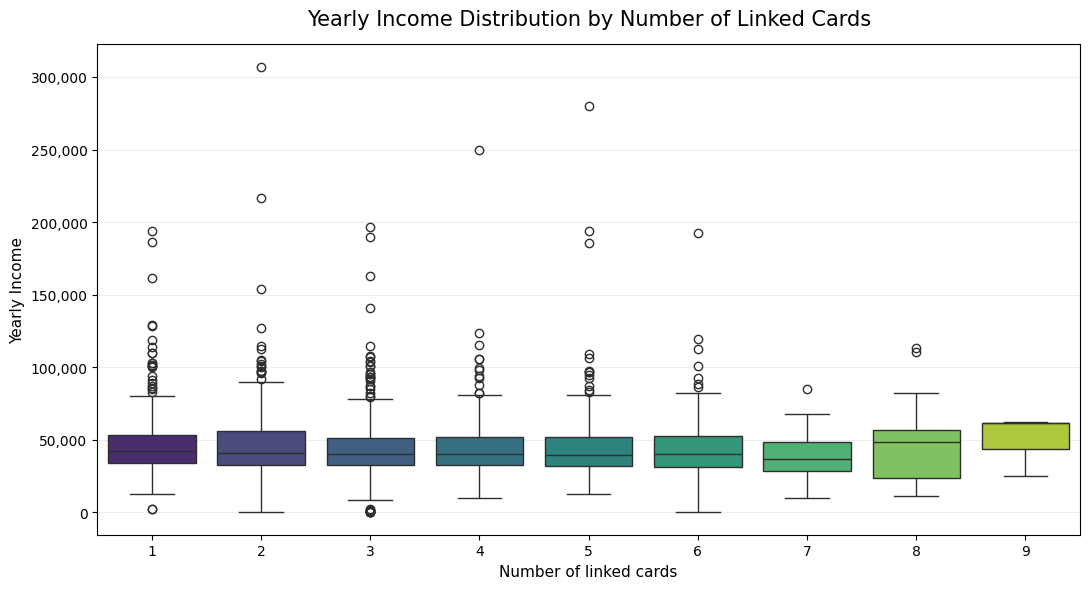

In [ ]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

sns.boxplot(
    x=users["num_credit_cards"],
    y=users["yearly_income"],
    ax=ax,
    palette="viridis"
)

ax.set_title(
    "Yearly Income Distribution by Number of Linked Cards",
    fontsize=15,
    pad=14
)

ax.set_xlabel(
    "Number of linked cards",
    fontsize=11
)

ax.set_ylabel(
    "Yearly Income",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:,.0f}"
    )
)

ax.grid(
    axis="y",
    alpha=0.22
)

fig.tight_layout()
plt.show()

### Income vs. Total Credit Card Capacity

In [ ]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.scatter(
    x=credit_holders["yearly_income"],
    y=credit_holders["total_credit_card_limit"],
    alpha=0.6,
    s=20,
    color="#4C78A8"
)

ax.set_title(
    "Total Credit Card Limit vs. Yearly Income for Credit Card Holders",
    fontsize=15,
    pad=14
)

ax.set_xlabel(
    "Yearly Income",
    fontsize=11
)

ax.set_ylabel(
    "Total Credit Card Limit",
    fontsize=11
)

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:,.0f}"
    )
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:,.0f}"
    )
)

ax.grid(
    axis="both",
    alpha=0.22
)

fig.tight_layout()
plt.show()

### Total Debt vs. Number of Credit Cards

/tmp/ipykernel_3927/2306879789.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


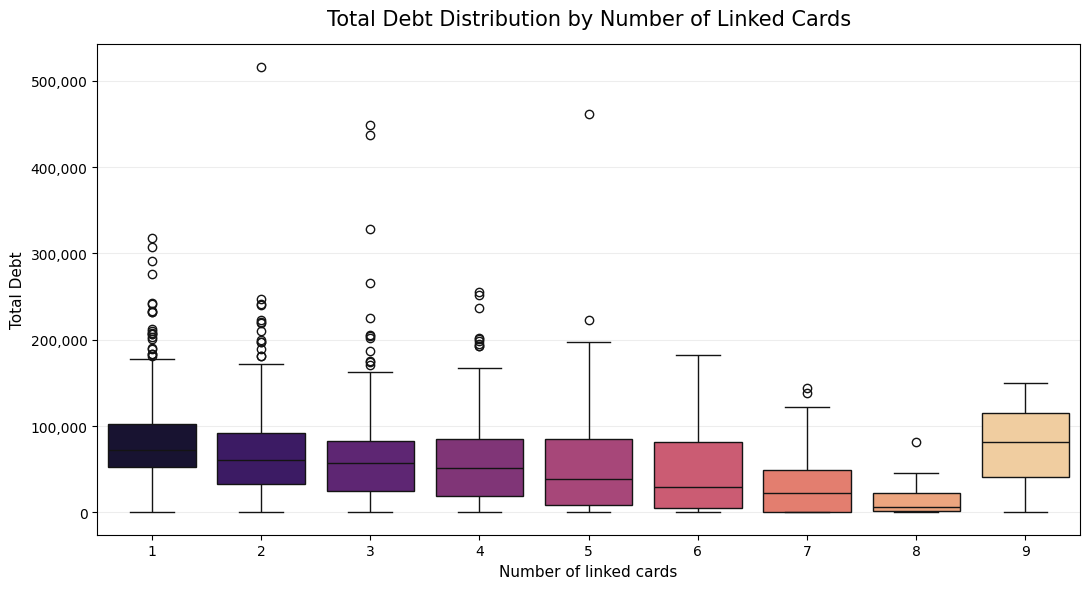

In [ ]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

sns.boxplot(
    x=users["num_credit_cards"],
    y=users["total_debt"],
    ax=ax,
    palette="magma"
)

ax.set_title(
    "Total Debt Distribution by Number of Linked Cards",
    fontsize=15,
    pad=14
)

ax.set_xlabel(
    "Number of linked cards",
    fontsize=11
)

ax.set_ylabel(
    "Total Debt",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:,.0f}"
    )
)

ax.grid(
    axis="y",
    alpha=0.22
)

fig.tight_layout()
plt.show()

### Credit Score vs. Number of Credit Cards

/tmp/ipykernel_3927/3714262058.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


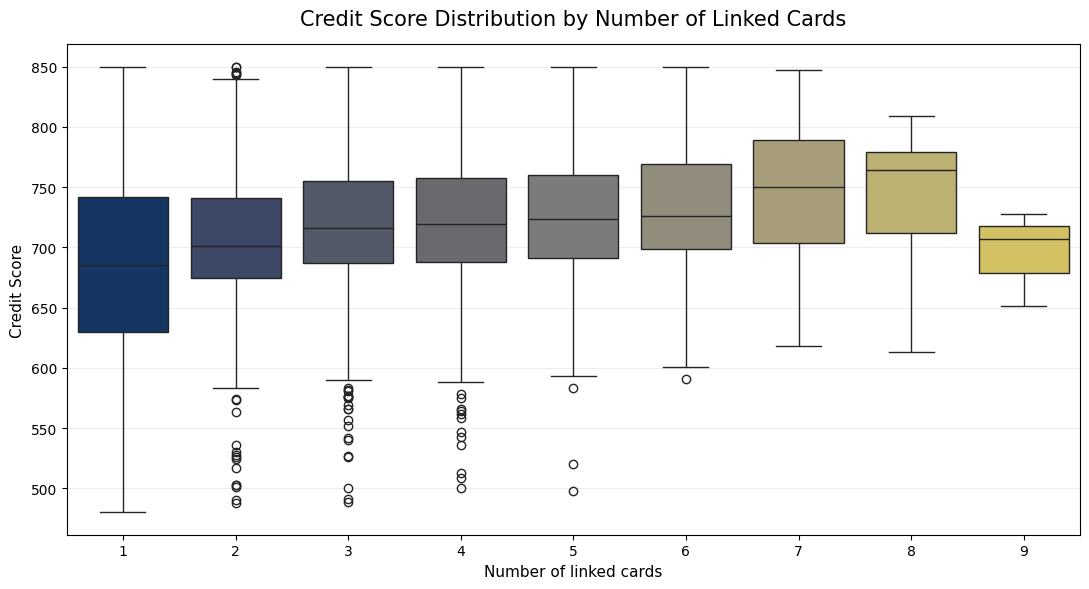

In [ ]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

sns.boxplot(
    x=users["num_credit_cards"],
    y=users["credit_score"],
    ax=ax,
    palette="cividis"
)

ax.set_title(
    "Credit Score Distribution by Number of Linked Cards",
    fontsize=15,
    pad=14
)

ax.set_xlabel(
    "Number of linked cards",
    fontsize=11
)

ax.set_ylabel(
    "Credit Score",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:,.0f}"
    )
)

ax.grid(
    axis="y",
    alpha=0.22
)

fig.tight_layout()
plt.show()

In [ ]:
credit_capacity_correlations = {
    "income_vs_total_credit_limit_pearson": (
        credit_holders["yearly_income"]
        .corr(
            credit_holders["total_credit_card_limit"],
            method="pearson"
        )
    ),

    "income_vs_total_credit_limit_spearman": (
        credit_holders["yearly_income"]
        .corr(
            credit_holders["total_credit_card_limit"],
            method="spearman"
        )
    ),

    "income_vs_credit_limit_to_income_ratio_spearman": (
        credit_holders["yearly_income"]
        .corr(
            credit_holders["credit_limit_to_income_ratio"],
            method="spearman"
        )
    ),
}

credit_capacity_correlations

{'income_vs_total_credit_limit_pearson': np.float64(0.5575914981436687),
 'income_vs_total_credit_limit_spearman': np.float64(0.4233790330457614),
 'income_vs_credit_limit_to_income_ratio_spearman': np.float64(-0.12352579962686479)}

### Distribution of Number of Credit Cards Per Customer

Field: num_credit_cards
Count: 2000
Mean: 3.073
Median: 3.0
Minimum: 1.0
Maximum: 9.0
Histogram bins: 8


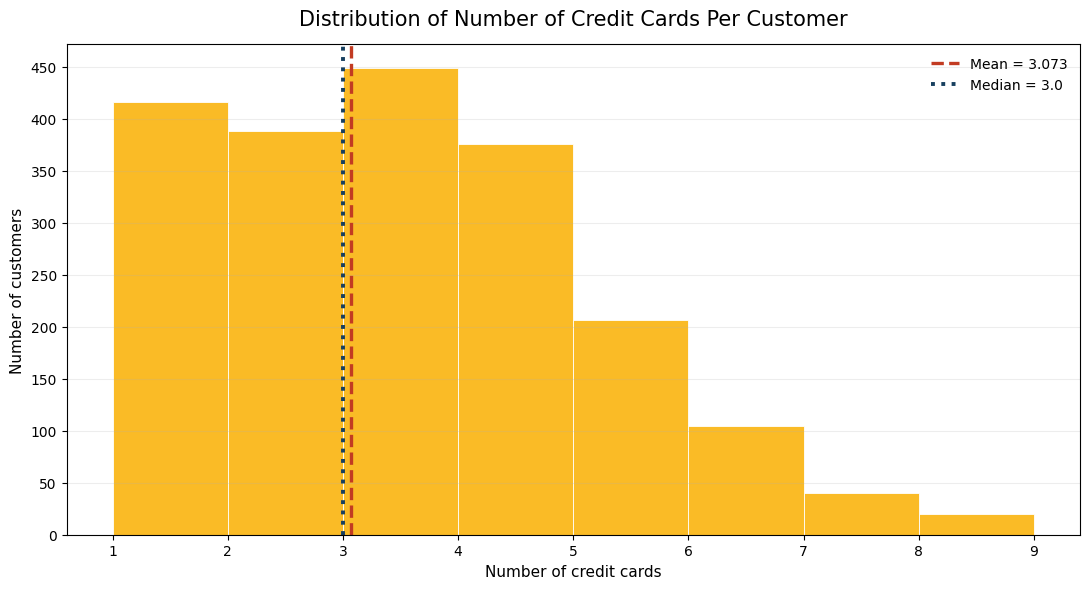

In [ ]:
# Code from 3ExGx2_sJ1Fm to ensure visual_fields is defined
visual_fields = [
    "yearly_income",
    "total_debt",
    "debt_to_annual_income_ratio"
]

# Definitions from RlABZDr_J4DH to ensure functions are in scope
def exact_number(value):
    """Return the stored float value without manual rounding."""
    return repr(float(value))


def plot_distribution(
    data,
    title,
    x_label,
    colour,
    comma_axis=False
):
    mean_value = data.mean()
    median_value = data.median()

    bin_edges = np.histogram_bin_edges(
        data.to_numpy(),
        bins="fd"
    )

    fig, ax = plt.subplots(
        figsize=(11, 6)
    )

    ax.hist(
        data,
        bins=bin_edges,
        color=colour,
        edgecolor="white",
        linewidth=0.7,
        alpha=0.85
    )

    ax.axvline(
        mean_value,
        color="#C23B22",
        linestyle="dashed",
        linewidth=2.4,
        label=f"Mean = {exact_number(mean_value)}"
    )

    ax.axvline(
        median_value,
        color="#173F5F",
        linestyle="dotted",
        linewidth=2.8,
        label=f"Median = {exact_number(median_value)}"
    )

    ax.set_title(
        title,
        fontsize=15,
        pad=14
    )

    ax.set_xlabel(
        x_label,
        fontsize=11
    )

    ax.set_ylabel(
        "Number of customers",
        fontsize=11
    )

    if comma_axis:
        ax.xaxis.set_major_formatter(
            FuncFormatter(
                lambda value, position: f"{value:,.0f}"
            )
        )

    ax.yaxis.set_major_locator(
        MaxNLocator(integer=True)
    )

    ax.grid(
        axis="y",
        alpha=0.22
    )

    ax.legend(
        frameon=False,
        fontsize=10
    )

    fig.tight_layout()

    print(f"Field: {data.name}")
    print(f"Count: {data.count()}")
    print(f"Mean: {exact_number(mean_value)}")
    print(f"Median: {exact_number(median_value)}")
    print(f"Minimum: {exact_number(data.min())}")
    print(f"Maximum: {exact_number(data.max())}")
    print(f"Histogram bins: {len(bin_edges) - 1}")

    plt.show()


# Original content of f1e0c471
plot_distribution(
    data=users["num_credit_cards"],
    title="Distribution of Number of Credit Cards Per Customer",
    x_label="Number of credit cards",
    colour="#FAB000",
    comma_axis=False
)

In [ ]:
credit_capacity_correlations = {
    "income_vs_total_credit_limit_pearson": (
        credit_holders["yearly_income"]
        .corr(
            credit_holders["total_credit_card_limit"],
            method="pearson"
        )
    ),

    "income_vs_total_credit_limit_spearman": (
        credit_holders["yearly_income"]
        .corr(
            credit_holders["total_credit_card_limit"],
            method="spearman"
        )
    ),

    "income_vs_credit_limit_to_income_ratio_spearman": (
        credit_holders["yearly_income"]
        .corr(
            credit_holders["credit_limit_to_income_ratio"],
            method="spearman"
        )
    ),
}

credit_capacity_correlations

{'income_vs_total_credit_limit_pearson': np.float64(0.5575914981436687),
 'income_vs_total_credit_limit_spearman': np.float64(0.4233790330457614),
 'income_vs_credit_limit_to_income_ratio_spearman': np.float64(-0.12352579962686479)}

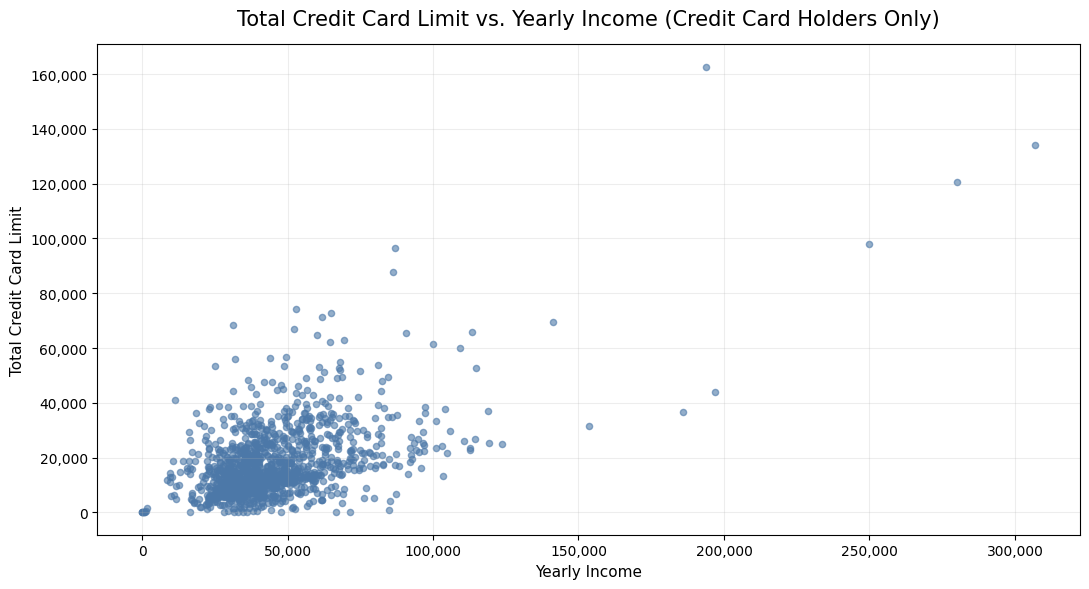

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.scatter(
    x=credit_holders['yearly_income'],
    y=credit_holders['total_credit_card_limit'],
    alpha=0.6,
    s=20,
    color='#4C78A8'
)

ax.set_title(
    'Total Credit Card Limit vs. Yearly Income (Credit Card Holders Only)',
    fontsize=15,
    pad=14
)

ax.set_xlabel('Yearly Income', fontsize=11)
ax.set_ylabel('Total Credit Card Limit', fontsize=11)

ax.xaxis.set_major_formatter(FuncFormatter(lambda value, position: f'{value:,.0f}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, position: f'{value:,.0f}'))

ax.grid(axis='both', alpha=0.22)

fig.tight_layout()
plt.show()

### Relative Credit Capacity Analysis

We examine if higher-income customers have higher credit limits relative to their income, or if the increase is strictly absolute.

Spearman correlation (Income vs. Credit Limit % of Income): np.float64(-0.12352579962686483)


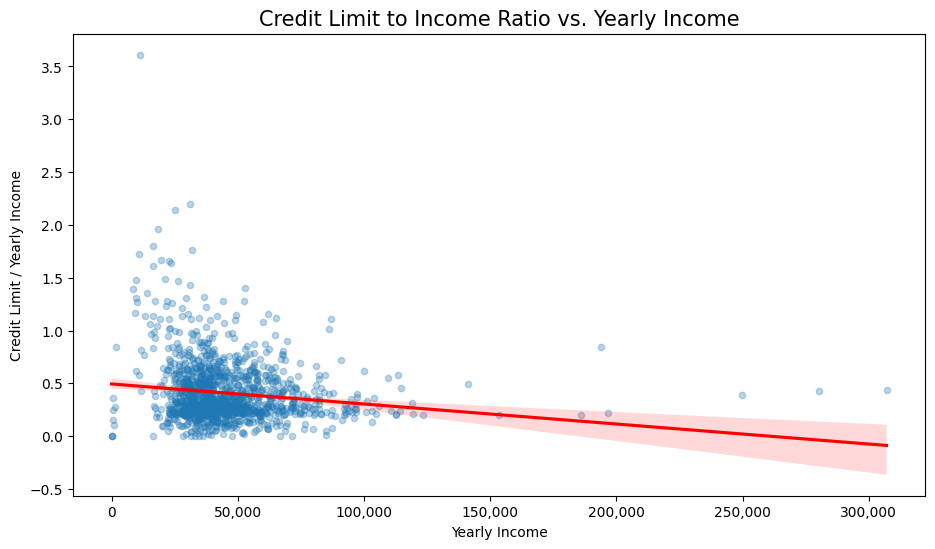

In [ ]:
income_ratio_corr = credit_holders[['yearly_income', 'credit_limit_to_income_ratio']].corr(method='spearman').iloc[0, 1]

print(f"Spearman correlation (Income vs. Credit Limit % of Income): {income_ratio_corr!r}")

# Visualization to see the trend
fig, ax = plt.subplots(figsize=(11, 6))
sns.regplot(
    x='yearly_income',
    y='credit_limit_to_income_ratio',
    data=credit_holders,
    scatter_kws={'alpha':0.3, 's':20},
    line_kws={'color':'red'},
    ax=ax
)

ax.set_title('Credit Limit to Income Ratio vs. Yearly Income', fontsize=15)
ax.set_xlabel('Yearly Income')
ax.set_ylabel('Credit Limit / Yearly Income')
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, pos: f'{value:,.0f}'))

plt.show()

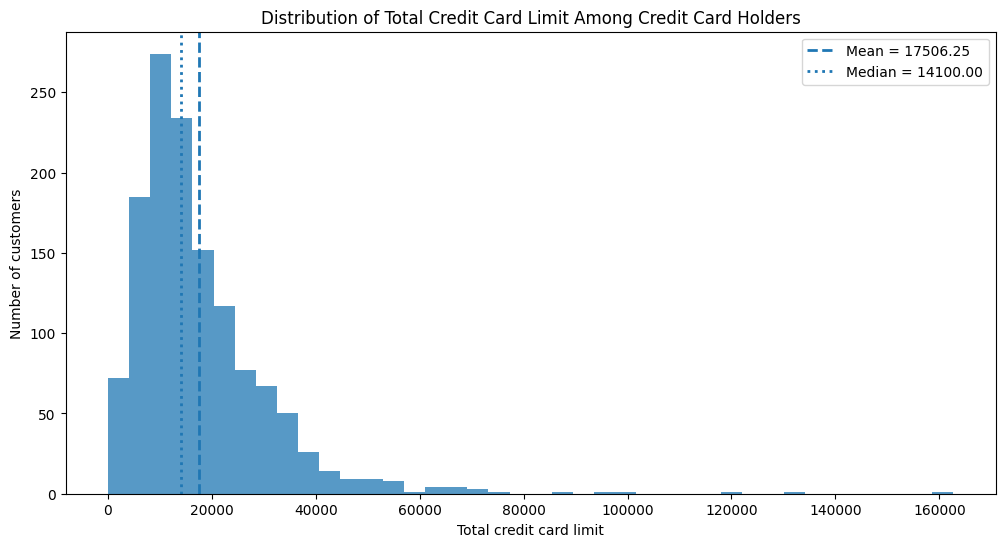

In [ ]:
plt.figure(figsize=(12, 6))

values = credit_holders[
    "total_credit_card_limit"
]

mean_value = values.mean()
median_value = values.median()

plt.hist(
    values,
    bins=40,
    alpha=0.75
)

plt.axvline(
    mean_value,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_value:.2f}"
)

plt.axvline(
    median_value,
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_value:.2f}"
)

plt.title(
    "Distribution of Total Credit Card Limit Among Credit Card Holders"
)

plt.xlabel(
    "Total credit card limit"
)

plt.ylabel(
    "Number of customers"
)

plt.legend()

plt.show()

In [ ]:
cards["acct_open_parsed"] = pd.to_datetime(
    cards["acct_open_date"],
    format="%Y-%m",
    errors="coerce"
)

opening_date_summary = {
    "earliest_open_month": cards["acct_open_parsed"].min(),
    "latest_open_month": cards["acct_open_parsed"].max(),
    "unique_open_months": cards["acct_open_parsed"].nunique(),
    "missing_open_dates": cards["acct_open_parsed"].isna().sum(),
}

opening_date_summary

{'earliest_open_month': Timestamp('1991-01-01 00:00:00'),
 'latest_open_month': Timestamp('2020-02-01 00:00:00'),
 'unique_open_months': 303,
 'missing_open_dates': np.int64(0)}

In [ ]:
cards["account_open_year"] = (
    cards["acct_open_parsed"].dt.year
)

cards_by_open_year = (
    cards["account_open_year"]
    .value_counts()
    .sort_index()
    .rename_axis("account_open_year")
    .reset_index(name="card_count")
)

cards_by_open_year

,account_open_year,card_count
0,1991,3
1,1992,2
2,1993,3
3,1994,10
4,1995,6
5,1996,16
6,1997,27
7,1998,42
8,1999,61
9,2000,64


In [ ]:
opening_by_card_type = (
    cards
    .groupby("card_type")[
        "acct_open_parsed"
    ]
    .agg(
        card_count="count",
        earliest_open="min",
        median_open="median",
        latest_open="max",
    )
)

opening_by_card_type

,card_count,earliest_open,median_open,latest_open
card_type,,,,
Credit,2057,1991-01-01,2010-02-01,2020-02-01
Debit,3511,1991-07-01,2010-03-01,2020-02-01
Debit (Prepaid),578,1994-12-01,2010-02-01,2020-02-01


In [ ]:
customer_card_history = (
    cards
    .groupby("client_id")
    .agg(
        first_card_open_month=(
            "acct_open_parsed",
            "min"
        ),
        most_recent_card_open_month=(
            "acct_open_parsed",
            "max"
        ),
        linked_card_count=(
            "card_id",
            "count"
        ),
    )
    .reset_index()
)

In [ ]:
customer_card_history[
    "portfolio_opening_span_months"
] = (
    (
        customer_card_history[
            "most_recent_card_open_month"
        ].dt.year
        -
        customer_card_history[
            "first_card_open_month"
        ].dt.year
    ) * 12
    +
    (
        customer_card_history[
            "most_recent_card_open_month"
        ].dt.month
        -
        customer_card_history[
            "first_card_open_month"
        ].dt.month
    )
)

customer_card_history[
    "portfolio_opening_span_months"
].describe()

,portfolio_opening_span_months
count,2000.0
mean,75.6075
std,70.96746884712265
min,0.0
25%,1.0
50%,68.0
75%,130.25
max,323.0


In [ ]:
portfolio_span_checks = {
    "span_equal_0_months": (
        customer_card_history[
            "portfolio_opening_span_months"
        ] == 0
    ).sum(),

    "span_0_to_1_month": (
        customer_card_history[
            "portfolio_opening_span_months"
        ] <= 1
    ).sum(),

    "span_12_months_or_less": (
        customer_card_history[
            "portfolio_opening_span_months"
        ] <= 12
    ).sum(),

    "span_60_months_or_more": (
        customer_card_history[
            "portfolio_opening_span_months"
        ] >= 60
    ).sum(),

    "span_120_months_or_more": (
        customer_card_history[
            "portfolio_opening_span_months"
        ] >= 120
    ).sum(),
}

portfolio_span_checks

{'span_equal_0_months': np.int64(495),
 'span_0_to_1_month': np.int64(628),
 'span_12_months_or_less': np.int64(683),
 'span_60_months_or_more': np.int64(1065),
 'span_120_months_or_more': np.int64(595)}

In [ ]:
cards_2020 = cards[
    cards["account_open_year"] == 2020
].copy()

cards_2020["account_open_month"] = (
    cards_2020["acct_open_parsed"].dt.month
)

cards_2020_month_summary = (
    cards_2020[
        "acct_open_parsed"
    ]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

cards_2020_month_summary

,count
acct_open_parsed,
2020-01,571
2020-02,607


In [ ]:
cards_2020_type_summary = (
    cards_2020["card_type"]
    .value_counts()
)

cards_2020_type_summary

,count
card_type,
Debit,646
Credit,402
Debit (Prepaid),130


In [ ]:
cards_2020_customer_summary = {
    "2020_cards": len(cards_2020),

    "customers_with_2020_card": (
        cards_2020["client_id"].nunique()
    ),

    "customers_with_multiple_2020_cards": (
        cards_2020
        .groupby("client_id")
        .size()
        .gt(1)
        .sum()
    ),
}

cards_2020_customer_summary

{'2020_cards': 1178,
 'customers_with_2020_card': 725,
 'customers_with_multiple_2020_cards': np.int64(294)}

In [14]:
import pandas as pd
from pathlib import Path

transactions_path = Path(
    "/content/transactions_data.csv"
)

chunk_size = 100_000

total_rows = 0
min_date = None
max_date = None

yearly_counts = {}

unique_customers = set()
unique_cards = set()

for chunk in pd.read_csv(
    transactions_path,
    usecols=[
        "date",
        "client_id",
        "card_id",
    ],
    chunksize=chunk_size
):
    chunk["date"] = pd.to_datetime(
        chunk["date"],
        format='mixed',
        errors="raise"
    )

    total_rows += len(chunk)

    chunk_min = chunk["date"].min()
    chunk_max = chunk["date"].max()

    min_date = (
        chunk_min
        if min_date is None
        else min(min_date, chunk_min)
    )

    max_date = (
        chunk_max
        if max_date is None
        else max(max_date, chunk_max)
    )

    year_counts = (
        chunk["date"]
        .dt.year
        .value_counts()
    )

    for year, count in year_counts.items():
        yearly_counts[year] = (
            yearly_counts.get(year, 0)
            + int(count)
        )

    unique_customers.update(
        chunk["client_id"].unique()
    )

    unique_cards.update(
        chunk["card_id"].unique()
    )


yearly_transaction_summary = (
    pd.Series(yearly_counts)
    .sort_index()
    .rename("transaction_count")
    .rename_axis("year")
    .reset_index()
)

print("Total transactions:", total_rows)
print("First transaction:", min_date)
print("Last transaction:", max_date)
print(
    "Customers represented:",
    len(unique_customers)
)
print(
    "Cards represented:",
    len(unique_cards)
)

yearly_transaction_summary

FileNotFoundError: [Errno 2] No such file or directory: '/content/transactions_data.csv'

In [ ]:
customer_transaction_counts = {}

for chunk in pd.read_csv(
    transactions_path,
    usecols=["client_id"],
    chunksize=chunk_size
):
    counts = (
        chunk["client_id"]
        .value_counts()
    )

    for client_id, count in counts.items():
        customer_transaction_counts[client_id] = (
            customer_transaction_counts.get(
                client_id,
                0
            )
            + int(count)
        )


customer_transaction_counts = (
    pd.Series(
        customer_transaction_counts,
        name="transaction_count"
    )
    .rename_axis("client_id")
    .reset_index()
)

customer_transaction_counts[
    "transaction_count"
].describe()

,transaction_count
count,1219.0
mean,10229.39704675964
std,5275.0617573042555
min,453.0
25%,6751.5
50%,9201.0
75%,12538.0
max,45496.0


In [ ]:
customer_activity_checks = {
    "customers_with_transactions": (
        len(customer_transaction_counts)
    ),

    "customers_without_transactions": (
        len(users)
        - len(customer_transaction_counts)
    ),

    "minimum_transactions_per_active_customer": (
        customer_transaction_counts[
            "transaction_count"
        ].min()
    ),

    "maximum_transactions_per_active_customer": (
        customer_transaction_counts[
            "transaction_count"
        ].max()
    ),
}

customer_activity_checks

{'customers_with_transactions': 1219,
 'customers_without_transactions': 781,
 'minimum_transactions_per_active_customer': 453,
 'maximum_transactions_per_active_customer': 45496}

In [18]:
from pathlib import Path
import pandas as pd


files = {
    "interim": Path(
        "/content/transactions_cleaned.csv"
    ),
    "processed": Path(
        "/content/transactions.csv"
    ),
}


for name, path in files.items():

    total_rows = 0
    min_date = None
    max_date = None

    unique_cards = set()
    unique_customers = set()

    for chunk in pd.read_csv(
        path,
        usecols=
            [
            "date",
            "client_id",
            "card_id",
        ],
        chunksize=100_000
    ):

        chunk["date"] = pd.to_datetime(
            chunk["date"],
            errors="coerce"
        )

        total_rows += len(chunk)

        chunk_min = chunk["date"].min()
        chunk_max = chunk["date"].max()

        min_date = (
            chunk_min
            if min_date is None
            else min(min_date, chunk_min)
        )

        max_date = (
            chunk_max
            if max_date is None
            else max(max_date, chunk_max)
        )

        unique_customers.update(
            chunk["client_id"].unique()
        )

        unique_cards.update(
            chunk["card_id"].unique()
        )

    print()
    print(name.upper())
    print("Rows:", total_rows)
    print("First:", min_date)
    print("Last:", max_date)
    print(
        "Customers:",
        len(unique_customers)
    )
    print(
        "Cards:",
        len(unique_cards)
    )


INTERIM
Rows: 243816
First: 2010-01-01 00:01:00
Last: 2010-03-15 16:46:00
Customers: 1100
Cards: 2556

PROCESSED
Rows: 13305915
First: 2010-01-01 00:01:00
Last: 2019-10-31 23:59:00
Customers: 1219
Cards: 4071


In [20]:
from pathlib import Path

DATA_DIR = Path("/content/")

users_path = DATA_DIR / "users.csv"
cards_path = DATA_DIR / "cards.csv"
transactions_path = DATA_DIR / "transactions.csv"
mcc_path = DATA_DIR / "mcc_codes.csv"
fraud_path = DATA_DIR / "fraud_labels.csv"

In [21]:
import hashlib
import pandas as pd


PROMOTION_RUN_ID = (
    "b14c3c6f-6a9d-4fb0-a20d-d7593c5d06bd"
)

FILE_MAP = {
    "users": "users.csv",
    "cards": "cards.csv",
    "transactions": "transactions.csv",
    "mcc_codes": "mcc_codes.csv",
    "fraud_labels": "fraud_labels.csv",
}


def sha256_file(path, chunk_size=8 * 1024 * 1024):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


manifest = pd.read_csv("/content/processed_promotion_manifest.csv")

certified_run = manifest[
    manifest["run_id"] == PROMOTION_RUN_ID
].copy()

results = []

for dataset, filename in FILE_MAP.items():

    path = DATA_DIR / filename

    expected = certified_run[
        certified_run["dataset"] == dataset
    ]

    if len(expected) != 1:
        raise ValueError(
            f"Expected exactly one manifest record "
            f"for {dataset}, found {len(expected)}"
        )

    expected_hash = (
        expected.iloc[0]["processed_sha256"]
    )

    actual_hash = sha256_file(path)

    results.append(
        {
            "dataset": dataset,
            "file_exists": path.exists(),
            "hash_match": (
                actual_hash == expected_hash
            ),
            "actual_sha256": actual_hash,
            "expected_sha256": expected_hash,
        }
    )


colab_integrity_check = pd.DataFrame(results)

colab_integrity_check

FileNotFoundError: [Errno 2] No such file or directory: '/content/processed_promotion_manifest.csv'

In [22]:
# ============================================================
# INVESTIGATE CURRENT COLAB TRANSACTION FILE
# ============================================================

transactions_path = (
    DATA_DIR
    / "transactions.csv"
)

print(
    "File:",
    transactions_path
)

print(
    "Size bytes:",
    transactions_path.stat().st_size
)

print(
    "Size GB:",
    round(
        transactions_path.stat().st_size
        / (1024 ** 3),
        4
    )
)

File: /content/transactions.csv
Size bytes: 1322013655
Size GB: 1.2312


In [23]:
# ============================================================
# CURRENT TRANSACTION FILE RECONCILIATION
# ============================================================

total_rows = 0
min_date = None
max_date = None

unique_customers = set()
unique_cards = set()

for chunk in pd.read_csv(
    transactions_path,
    usecols=[
        "date",
        "client_id",
        "card_id",
    ],
    chunksize=100_000
):

    chunk["date"] = pd.to_datetime(
        chunk["date"],
        format='mixed',
        errors="raise"
    )

    total_rows += len(chunk)

    chunk_min = chunk["date"].min()
    chunk_max = chunk["date"].max()

    min_date = (
        chunk_min
        if min_date is None
        else min(
            min_date,
            chunk_min
        )
    )

    max_date = (
        chunk_max
        if max_date is None
        else max(
            max_date,
            chunk_max
        )
    )

    unique_customers.update(
        chunk["client_id"].unique()
    )

    unique_cards.update(
        chunk["card_id"].unique()
    )


current_transaction_check = {
    "rows": total_rows,
    "first_transaction": min_date,
    "last_transaction": max_date,
    "customers": len(
        unique_customers
    ),
    "cards": len(
        unique_cards
    ),
}

current_transaction_check

{'rows': 13305915,
 'first_transaction': Timestamp('2010-01-01 00:01:00'),
 'last_transaction': Timestamp('2019-10-31 23:59:00'),
 'customers': 1219,
 'cards': 4071}

In [25]:
import pandas as pd


chunk_size = 100_000

total_rows = 0

min_date = None
max_date = None

unique_customers = set()
unique_cards = set()

yearly_counts = {}


for chunk in pd.read_csv(
    transactions_path,
    usecols=[
        "date",
        "client_id",
        "card_id",
    ],
    chunksize=chunk_size
):

    chunk["date"] = pd.to_datetime(
        chunk["date"],
        format='mixed',
        errors="raise"
    )


    # --------------------------------------------
    # Population
    # --------------------------------------------

    total_rows += len(
        chunk
    )


    # --------------------------------------------
    # Observation period
    # --------------------------------------------

    chunk_min = (
        chunk["date"].min()
    )

    chunk_max = (
        chunk["date"].max()
    )


    min_date = (
        chunk_min
        if min_date is None
        else min(
            min_date,
            chunk_min
        )
    )


    max_date = (
        chunk_max
        if max_date is None
        else max(
            max_date,
            chunk_max
        )
    )


    # --------------------------------------------
    # Customers
    # --------------------------------------------

    unique_customers.update(
        chunk[
            "client_id"
        ].unique()
    )


    # --------------------------------------------
    # Cards
    # --------------------------------------------

    unique_cards.update(
        chunk[
            "card_id"
        ].unique()
    )


    # --------------------------------------------
    # Yearly volume
    # --------------------------------------------

    chunk_year_counts = (
        chunk["date"]
        .dt.year
        .value_counts()
    )


    for year, count in (
        chunk_year_counts.items()
    ):

        yearly_counts[
            int(year)
        ] = (
            yearly_counts.get(
                int(year),
                0
            )
            + int(count)
        )


yearly_transaction_summary = (
    pd.Series(
        yearly_counts,
        name="transaction_count"
    )
    .sort_index()
    .rename_axis(
        "year"
    )
    .reset_index()
)


print(
    "Total transactions:",
    f"{total_rows:,}"
)

print(
    "First transaction:",
    min_date
)

print(
    "Last transaction:",
    max_date
)

print(
    "Customers represented:",
    len(
        unique_customers
    )
)

print(
    "Cards represented:",
    len(
        unique_cards
    )
)

yearly_transaction_summary

Total transactions: 13,305,915
First transaction: 2010-01-01 00:01:00
Last transaction: 2019-10-31 23:59:00
Customers represented: 1219
Cards represented: 4071


,year,transaction_count
0,2010,1240880
1,2011,1290770
2,2012,1321672
3,2013,1352808
4,2014,1365537
5,2015,1388065
6,2016,1392117
7,2017,1399308
8,2018,1394792
9,2019,1159966


In [26]:
# ============================================================
# MONTHLY TRANSACTION ACTIVITY
# ============================================================

monthly_counts = {}

monthly_customers = {}

for chunk in pd.read_csv(
    transactions_path,
    usecols=[
        "date",
        "client_id",
    ],
    chunksize=100_000
):

    chunk["date"] = pd.to_datetime(
        chunk["date"],
        format='mixed',
        errors="raise"
    )

    chunk["year_month"] = (
        chunk["date"]
        .dt.to_period("M")
    )

    # --------------------------------------------------------
    # Transactions per month
    # --------------------------------------------------------

    month_transaction_counts = (
        chunk["year_month"]
        .value_counts()
    )

    for month, count in (
        month_transaction_counts.items()
    ):

        monthly_counts[month] = (
            monthly_counts.get(
                month,
                0
            )
            + int(count)
        )

    # --------------------------------------------------------
    # Active customers per month
    # --------------------------------------------------------

    for month, group in (
        chunk.groupby("year_month")
    ):

        if month not in monthly_customers:
            monthly_customers[month] = set()

        monthly_customers[
            month
        ].update(
            group[
                "client_id"
            ].unique()
        )


monthly_transaction_summary = (
    pd.DataFrame(
        {
            "year_month": sorted(
                monthly_counts.keys()
            )
        }
    )
)


monthly_transaction_summary[
    "transaction_count"
] = (
    monthly_transaction_summary[
        "year_month"
    ]
    .map(
        monthly_counts
    )
)


monthly_transaction_summary[
    "active_customers"
] = (
    monthly_transaction_summary[
        "year_month"
    ]
    .map(
        lambda month:
            len(
                monthly_customers[
                    month
                ]
            )
    )
)


monthly_transaction_summary[
    "transactions_per_active_customer"
] = (
    monthly_transaction_summary[
        "transaction_count"
    ]
    /
    monthly_transaction_summary[
        "active_customers"
    ]
)


monthly_transaction_summary

,year_month,transaction_count,active_customers,transactions_per_active_customer
0,2010-01,101209,1083,93.452447
1,2010-02,93470,1097,85.205105
2,2010-03,103345,1097,94.206928
3,2010-04,100169,1102,90.897459
4,2010-05,104773,1108,94.560469
...,...,...,...,...
113,2019-06,115014,1206,95.368159
114,2019-07,118906,1206,98.595357
115,2019-08,118905,1206,98.594527
116,2019-09,114771,1206,95.166667


In [27]:
monthly_transaction_summary[
    [
        "transaction_count",
        "active_customers",
        "transactions_per_active_customer",
    ]
].describe()

,transaction_count,active_customers,transactions_per_active_customer
count,118.000000,118.000000,118.000000
mean,112761.991525,1181.076271,95.440268
std,5496.121469,30.251413,3.083415
min,93470.000000,1083.000000,85.205105
25%,109068.000000,1165.750000,94.525575
50%,114557.000000,1191.000000,95.755581
75%,117692.250000,1205.000000,98.000623
max,119396.000000,1207.000000,99.413822


In [28]:
monthly_activity_checks = {
    "number_of_observed_months": (
        len(
            monthly_transaction_summary
        )
    ),

    "minimum_monthly_transactions": (
        monthly_transaction_summary[
            "transaction_count"
        ].min()
    ),

    "maximum_monthly_transactions": (
        monthly_transaction_summary[
            "transaction_count"
        ].max()
    ),

    "minimum_monthly_active_customers": (
        monthly_transaction_summary[
            "active_customers"
        ].min()
    ),

    "maximum_monthly_active_customers": (
        monthly_transaction_summary[
            "active_customers"
        ].max()
    ),
}

monthly_activity_checks

{'number_of_observed_months': 118,
 'minimum_monthly_transactions': 93470,
 'maximum_monthly_transactions': 119396,
 'minimum_monthly_active_customers': 1083,
 'maximum_monthly_active_customers': 1207}

In [29]:
minimum_transaction_month = (
    monthly_transaction_summary.loc[
        monthly_transaction_summary[
            "transaction_count"
        ].idxmin()
    ]
)

maximum_transaction_month = (
    monthly_transaction_summary.loc[
        monthly_transaction_summary[
            "transaction_count"
        ].idxmax()
    ]
)

print(
    "Minimum transaction month:"
)

print(
    minimum_transaction_month
)

print()

print(
    "Maximum transaction month:"
)

print(
    maximum_transaction_month
)

Minimum transaction month:
year_month                            2010-02
transaction_count                       93470
active_customers                         1097
transactions_per_active_customer    85.205105
Name: 1, dtype: object

Maximum transaction month:
year_month                            2015-12
transaction_count                      119396
active_customers                         1201
transactions_per_active_customer    99.413822
Name: 71, dtype: object


In [30]:
monthly_transaction_summary[
    "days_in_month"
] = (
    monthly_transaction_summary[
        "year_month"
    ]
    .dt.days_in_month
)

In [31]:
monthly_transaction_summary[
    "transactions_per_day"
] = (
    monthly_transaction_summary[
        "transaction_count"
    ]
    /
    monthly_transaction_summary[
        "days_in_month"
    ]
)


monthly_transaction_summary[
    "transactions_per_active_customer_per_day"
] = (
    monthly_transaction_summary[
        "transaction_count"
    ]
    /
    (
        monthly_transaction_summary[
            "active_customers"
        ]
        *
        monthly_transaction_summary[
            "days_in_month"
        ]
    )
)

In [32]:
monthly_transaction_summary[
    [
        "transaction_count",
        "active_customers",
        "transactions_per_day",
        "transactions_per_active_customer",
        "transactions_per_active_customer_per_day",
    ]
].describe()

,transaction_count,active_customers,transactions_per_day,transactions_per_active_customer,transactions_per_active_customer_per_day
count,118.000000,118.000000,118.000000,118.000000,118.000000
mean,112761.991525,1181.076271,3705.130425,95.440268,3.136034
std,5496.121469,30.251413,144.538981,3.083415,0.046843
min,93470.000000,1083.000000,3264.806452,85.205105,2.987566
25%,109068.000000,1165.750000,3625.201613,94.525575,3.100933
50%,114557.000000,1191.000000,3756.973118,95.755581,3.153014
75%,117692.250000,1205.000000,3820.975806,98.000623,3.172153
max,119396.000000,1207.000000,3851.483871,99.413822,3.206897


In [33]:
min_daily_activity_month = (
    monthly_transaction_summary.loc[
        monthly_transaction_summary[
            "transactions_per_day"
        ].idxmin()
    ]
)

max_daily_activity_month = (
    monthly_transaction_summary.loc[
        monthly_transaction_summary[
            "transactions_per_day"
        ].idxmax()
    ]
)


print("Minimum daily activity month:")
print(
    min_daily_activity_month
)

print()

print("Maximum daily activity month:")
print(
    max_daily_activity_month
)

Minimum daily activity month:
year_month                                      2010-01
transaction_count                                101209
active_customers                                   1083
transactions_per_active_customer              93.452447
days_in_month                                        31
transactions_per_day                        3264.806452
transactions_per_active_customer_per_day       3.014595
Name: 0, dtype: object

Maximum daily activity month:
year_month                                      2015-12
transaction_count                                119396
active_customers                                   1201
transactions_per_active_customer              99.413822
days_in_month                                        31
transactions_per_day                        3851.483871
transactions_per_active_customer_per_day       3.206897
Name: 71, dtype: object


In [34]:
monthly_relationships = {
    "transaction_count_vs_active_customers_pearson": (
        monthly_transaction_summary[
            "transaction_count"
        ]
        .corr(
            monthly_transaction_summary[
                "active_customers"
            ],
            method="pearson"
        )
    ),

    "transactions_per_day_vs_active_customers_pearson": (
        monthly_transaction_summary[
            "transactions_per_day"
        ]
        .corr(
            monthly_transaction_summary[
                "active_customers"
            ],
            method="pearson"
        )
    ),

    "transactions_per_day_vs_active_customers_spearman": (
        monthly_transaction_summary[
            "transactions_per_day"
        ]
        .corr(
            monthly_transaction_summary[
                "active_customers"
            ],
            method="spearman"
        )
    ),
}

monthly_relationships

{'transaction_count_vs_active_customers_pearson': np.float64(0.801434886511216),
 'transactions_per_day_vs_active_customers_pearson': np.float64(0.9828382535742592),
 'transactions_per_day_vs_active_customers_spearman': np.float64(0.9334335470062092)}

In [35]:
monthly_transaction_summary[
    "calendar_month"
] = (
    monthly_transaction_summary[
        "year_month"
    ].dt.month
)


seasonal_activity = (
    monthly_transaction_summary
    .groupby(
        "calendar_month"
    )
    .agg(
        observed_years=(
            "year_month",
            "count"
        ),
        average_transactions_per_day=(
            "transactions_per_day",
            "mean"
        ),
        median_transactions_per_day=(
            "transactions_per_day",
            "median"
        ),
        average_active_customers=(
            "active_customers",
            "mean"
        ),
        average_transactions_per_active_customer_per_day=(
            "transactions_per_active_customer_per_day",
            "mean"
        ),
    )
    .reset_index()
)

seasonal_activity

,calendar_month,observed_years,average_transactions_per_day,median_transactions_per_day,average_active_customers,average_transactions_per_active_customer_per_day
0,1,10,3674.693548,3754.403226,1175.500000,3.124422
1,2,10,3657.860837,3710.107143,1177.400000,3.105546
2,3,10,3694.806452,3772.080645,1177.600000,3.136205
3,4,10,3687.273333,3749.450000,1178.700000,3.127027
4,5,10,3697.400000,3754.967742,1180.800000,3.130257
5,6,10,3728.406667,3784.700000,1182.100000,3.153061
6,7,10,3721.532258,3783.903226,1183.900000,3.142474
7,8,10,3731.848387,3788.661290,1182.800000,3.154426
8,9,10,3725.983333,3780.583333,1183.300000,3.148113
9,10,10,3705.283871,3750.661290,1183.900000,3.128949


In [36]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("/content/")
transactions_path = DATA_DIR / "transactions.csv"

customer_stats = {}

for chunk in pd.read_csv(
    transactions_path,
    usecols=[
        "date",
        "client_id",
    ],
    chunksize=100_000
):

    chunk["date"] = pd.to_datetime(
        chunk["date"],
        format='mixed',
        errors="raise"
    )

    chunk["year_month"] = (
        chunk["date"]
        .dt.to_period("M")
    )

    for client_id, group in (
        chunk.groupby("client_id")
    ):

        if client_id not in customer_stats:

            customer_stats[client_id] = {
                "transaction_count": 0,
                "first_transaction": None,
                "last_transaction": None,
                "active_months": set(),
            }

        record = customer_stats[
            client_id
        ]

        record[
            "transaction_count"
        ] += len(group)

        group_min = (
            group["date"].min()
        )

        group_max = (
            group["date"].max()
        )

        record[
            "first_transaction"
        ] = (
            group_min
            if record[
                "first_transaction"
            ] is None
            else min(
                record[
                    "first_transaction"
                ],
                group_min
            )
        )

        record[
            "last_transaction"
        ] = (
            group_max
            if record[
                "last_transaction"
            ] is None
            else max(
                record[
                    "last_transaction"
                ],
                group_max
            )
        )

        record[
            "active_months"
        ].update(
            group[
                "year_month"
            ].unique()
        )

In [37]:
import pandas as pd

customer_activity = pd.DataFrame(
    [
        {
            "client_id": client_id,

            "transaction_count":
                values[
                    "transaction_count"
                ],

            "first_transaction":
                values[
                    "first_transaction"
                ],

            "last_transaction":
                values[
                    "last_transaction"
                ],

            "active_month_count":
                len(
                    values[
                        "active_months"
                    ]
                ),
        }

        for client_id, values
        in customer_stats.items()
    ]
)

In [38]:
customer_activity[
    "observed_month_span"
] = (
    (
        customer_activity[
            "last_transaction"
        ].dt.year
        -
        customer_activity[
            "first_transaction"
        ].dt.year
    ) * 12
    +
    (
        customer_activity[
            "last_transaction"
        ].dt.month
        -
        customer_activity[
            "first_transaction"
        ].dt.month
    )
    + 1
)

In [39]:
customer_activity[
    "active_month_ratio"
] = (
    customer_activity[
        "active_month_count"
    ]
    /
    customer_activity[
        "observed_month_span"
    ]
)

In [40]:
customer_activity[
    "transactions_per_active_month"
] = (
    customer_activity[
        "transaction_count"
    ]
    /
    customer_activity[
        "active_month_count"
    ]
)

In [41]:
# ============================================================
# CUSTOMER TRANSACTION ACTIVITY PROFILE
# ============================================================

customer_stats = {}

for chunk in pd.read_csv(
    transactions_path,
    usecols=[
        "date",
        "client_id",
    ],
    chunksize=100_000
):

    chunk["date"] = pd.to_datetime(
        chunk["date"],
        format='mixed',
        errors="raise"
    )

    chunk["year_month"] = (
        chunk["date"]
        .dt.to_period("M")
    )

    for client_id, group in (
        chunk.groupby("client_id")
    ):

        if client_id not in customer_stats:

            customer_stats[client_id] = {
                "transaction_count": 0,
                "first_transaction": None,
                "last_transaction": None,
                "active_months": set(),
            }

        record = customer_stats[
            client_id
        ]

        record[
            "transaction_count"
        ] += len(group)

        group_min = (
            group["date"].min()
        )

        group_max = (
            group["date"].max()
        )

        record[
            "first_transaction"
        ] = (
            group_min
            if record[
                "first_transaction"
            ] is None
            else min(
                record[
                    "first_transaction"
                ],
                group_min
            )
        )

        record[
            "last_transaction"
        ] = (
            group_max
            if record[
                "last_transaction"
            ] is None
            else max(
                record[
                    "last_transaction"
                ],
                group_max
            )
        )

        record[
            "active_months"
        ].update(
            group[
                "year_month"
            ].unique()
        )

In [42]:
customer_activity = pd.DataFrame(
    [
        {
            "client_id": client_id,

            "transaction_count":
                values[
                    "transaction_count"
                ],

            "first_transaction":
                values[
                    "first_transaction"
                ],

            "last_transaction":
                values[
                    "last_transaction"
                ],

            "active_month_count":
                len(
                    values[
                        "active_months"
                    ]
                ),
        }

        for client_id, values
        in customer_stats.items()
    ]
)

In [43]:
customer_activity[
    "observed_month_span"
] = (
    (
        customer_activity[
            "last_transaction"
        ].dt.year
        -
        customer_activity[
            "first_transaction"
        ].dt.year
    ) * 12
    +
    (
        customer_activity[
            "last_transaction"
        ].dt.month
        -
        customer_activity[
            "first_transaction"
        ].dt.month
    )
    + 1
)

In [44]:
customer_activity[
    "active_month_ratio"
] = (
    customer_activity[
        "active_month_count"
    ]
    /
    customer_activity[
        "observed_month_span"
    ]
)

In [45]:
customer_activity[
    "transactions_per_active_month"
] = (
    customer_activity[
        "transaction_count"
    ]
    /
    customer_activity[
        "active_month_count"
    ]
)

In [46]:
customer_activity[
    [
        "transaction_count",
        "active_month_count",
        "observed_month_span",
        "active_month_ratio",
        "transactions_per_active_month",
    ]
].describe()

,transaction_count,active_month_count,observed_month_span,active_month_ratio,transactions_per_active_month
count,1219.000000,1219.000000,1219.000000,1219.000000,1219.000000
mean,10915.434783,114.328958,114.803938,0.995108,95.021034
std,5607.355367,13.074847,11.832511,0.042549,46.788308
min,760.000000,22.000000,28.000000,0.186441,18.389831
25%,7223.500000,118.000000,118.000000,1.000000,63.394068
50%,9832.000000,118.000000,118.000000,1.000000,85.288136
75%,13349.000000,118.000000,118.000000,1.000000,114.457627
max,48479.000000,118.000000,118.000000,1.000000,410.838983


In [47]:
customer_activity_checks = {
    "active_customers": (
        len(
            customer_activity
        )
    ),

    "customers_active_all_observed_months": (
        customer_activity[
            "active_month_ratio"
        ]
        .eq(1)
        .sum()
    ),

    "customers_active_less_than_half_observed_months": (
        customer_activity[
            "active_month_ratio"
        ]
        .lt(0.5)
        .sum()
    ),

    "minimum_active_months": (
        customer_activity[
            "active_month_count"
        ].min()
    ),

    "maximum_active_months": (
        customer_activity[
            "active_month_count"
        ].max()
    ),
}

customer_activity_checks

{'active_customers': 1219,
 'customers_active_all_observed_months': np.int64(1178),
 'customers_active_less_than_half_observed_months': np.int64(2),
 'minimum_active_months': 22,
 'maximum_active_months': 118}

In [48]:
customer_activity_sorted = (
    customer_activity
    .sort_values(
        "transaction_count",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

total_transactions_check = (
    customer_activity_sorted[
        "transaction_count"
    ].sum()
)

top_10_customer_count = int(
    len(
        customer_activity_sorted
    ) * 0.10
)

top_20_customer_count = int(
    len(
        customer_activity_sorted
    ) * 0.20
)


concentration_checks = {
    "reconciled_transactions": (
        total_transactions_check
    ),

    "top_10_percent_customer_count": (
        top_10_customer_count
    ),

    "top_10_percent_transaction_share": (
        customer_activity_sorted
        .head(
            top_10_customer_count
        )[
            "transaction_count"
        ]
        .sum()
        /
        total_transactions_check
    ),

    "top_20_percent_customer_count": (
        top_20_customer_count
    ),

    "top_20_percent_transaction_share": (
        customer_activity_sorted
        .head(
            top_20_customer_count
        )[
            "transaction_count"
        ]
        .sum()
        /
        total_transactions_check
    ),
}

concentration_checks

{'reconciled_transactions': np.int64(13305915),
 'top_10_percent_customer_count': 121,
 'top_10_percent_transaction_share': np.float64(0.20938635185930468),
 'top_20_percent_customer_count': 243,
 'top_20_percent_transaction_share': np.float64(0.3572990658665714)}

In [49]:
customer_activity_relationships = {
    "transaction_count_vs_active_month_count_pearson": (
        customer_activity[
            "transaction_count"
        ]
        .corr(
            customer_activity[
                "active_month_count"
            ],
            method="pearson"
        )
    ),

    "transaction_count_vs_active_month_count_spearman": (
        customer_activity[
            "transaction_count"
        ]
        .corr(
            customer_activity[
                "active_month_count"
            ],
            method="spearman"
        )
    ),

    "transaction_count_vs_transactions_per_active_month_pearson": (
        customer_activity[
            "transaction_count"
        ]
        .corr(
            customer_activity[
                "transactions_per_active_month"
            ],
            method="pearson"
        )
    ),

    "transaction_count_vs_transactions_per_active_month_spearman": (
        customer_activity[
            "transaction_count"
        ]
        .corr(
            customer_activity[
                "transactions_per_active_month"
            ],
            method="spearman"
        )
    ),
}

customer_activity_relationships

{'transaction_count_vs_active_month_count_pearson': np.float64(0.26884088287983166),
 'transaction_count_vs_active_month_count_spearman': np.float64(0.30579878673765604),
 'transaction_count_vs_transactions_per_active_month_pearson': np.float64(0.9784653562737055),
 'transaction_count_vs_transactions_per_active_month_spearman': np.float64(0.9674890764290318)}

In [50]:
partial_history_customers = (
    customer_activity[
        customer_activity[
            "active_month_count"
        ] < 118
    ]
    .copy()
)

partial_history_customers[
    [
        "transaction_count",
        "first_transaction",
        "last_transaction",
        "active_month_count",
        "observed_month_span",
        "active_month_ratio",
        "transactions_per_active_month",
    ]
].describe()

,transaction_count,first_transaction,last_transaction,active_month_count,observed_month_span,active_month_ratio,transactions_per_active_month
count,158.000000,158,158,158.000000,158.000000,158.000000,158.000000
mean,7268.721519,2011-10-09 18:20:14.810126592,2019-07-15 14:26:43.670885888,89.677215,93.341772,0.962256,81.021162
min,760.000000,2010-01-01 02:35:00,2013-01-31 16:37:00,22.000000,28.000000,0.186441,24.263158
25%,4166.000000,2010-03-27 10:59:15,2019-10-31 09:41:15,77.250000,79.000000,0.991167,56.903654
50%,6767.000000,2011-01-01 19:15:30,2019-10-31 14:38:00,97.000000,101.000000,1.000000,73.527880
75%,9008.500000,2012-09-15 06:49:15,2019-10-31 18:40:00,109.750000,113.000000,1.000000,98.380279
max,30672.000000,2017-07-01 01:44:00,2019-10-31 23:56:00,117.000000,118.000000,1.000000,312.979592
std,4093.758435,NaN,NaN,24.971645,23.528482,0.113126,39.318772


In [51]:
partial_history_checks = {
    "partial_history_customers": (
        len(
            partial_history_customers
        )
    ),

    "started_after_2010": (
        partial_history_customers[
            "first_transaction"
        ]
        .dt.year
        .gt(2010)
        .sum()
    ),

    "ended_before_2019": (
        partial_history_customers[
            "last_transaction"
        ]
        .dt.year
        .lt(2019)
        .sum()
    ),

    "active_month_ratio_below_0_90": (
        partial_history_customers[
            "active_month_ratio"
        ]
        .lt(0.90)
        .sum()
    ),
}

partial_history_checks

{'partial_history_customers': 158,
 'started_after_2010': np.int64(82),
 'ended_before_2019': np.int64(13),
 'active_month_ratio_below_0_90': np.int64(17)}

In [52]:
# ============================================================
# PHASE 10.4
# TRANSACTION VALUE ANALYSIS
# ============================================================

import pandas as pd
import numpy as np


amounts = pd.read_csv(
    transactions_path,
    usecols=["amount"],
    dtype={
        "amount": "float64"
    }
)


print(
    "Rows loaded:",
    f"{len(amounts):,}"
)

print(
    "Missing amounts:",
    f"{amounts['amount'].isna().sum():,}"
)

Rows loaded: 13,305,915
Missing amounts: 0


In [53]:
assert len(amounts) == 13_305_915

assert (
    amounts["amount"]
    .isna()
    .sum()
    == 0
)

print(
    "AMOUNT POPULATION RECONCILIATION: PASS"
)

AMOUNT POPULATION RECONCILIATION: PASS


In [54]:
amount_distribution = (
    amounts["amount"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

amount_distribution

,amount
count,1.330592e+07
mean,4.297604e+01
std,8.165575e+01
min,-5.000000e+02
1%,-9.600000e+01
5%,0.000000e+00
10%,1.720000e+00
25%,8.930000e+00
50%,2.899000e+01
75%,6.371000e+01


In [55]:
amounts["amount_sign"] = np.select(
    [
        amounts["amount"] < 0,
        amounts["amount"] == 0,
        amounts["amount"] > 0,
    ],
    [
        "Negative",
        "Zero",
        "Positive",
    ],
    default="Unexpected"
)

In [56]:
amount_sign_summary = (
    amounts[
        "amount_sign"
    ]
    .value_counts()
    .rename_axis(
        "amount_sign"
    )
    .reset_index(
        name="transaction_count"
    )
)


amount_sign_summary[
    "transaction_share"
] = (
    amount_sign_summary[
        "transaction_count"
    ]
    /
    len(amounts)
)


amount_sign_summary

,amount_sign,transaction_count,transaction_share
0,Positive,12635227,0.949595
1,Negative,660049,0.049606
2,Zero,10639,0.000800


In [57]:
expected_sign_counts = {
    "Negative": 660_049,
    "Zero": 10_639,
    "Positive": 12_635_227,
}


actual_sign_counts = (
    amounts[
        "amount_sign"
    ]
    .value_counts()
    .to_dict()
)


assert (
    actual_sign_counts
    == expected_sign_counts
)

print(
    "TRANSACTION SIGN RECONCILIATION: PASS"
)

TRANSACTION SIGN RECONCILIATION: PASS


In [58]:
amount_value_summary = (
    amounts
    .groupby(
        "amount_sign",
        observed=True
    )
    .agg(
        transaction_count=(
            "amount",
            "size"
        ),

        total_signed_amount=(
            "amount",
            "sum"
        ),

        mean_amount=(
            "amount",
            "mean"
        ),

        median_amount=(
            "amount",
            "median"
        ),

        minimum_amount=(
            "amount",
            "min"
        ),

        maximum_amount=(
            "amount",
            "max"
        ),
    )
    .reset_index()
)


amount_value_summary

,amount_sign,transaction_count,total_signed_amount,mean_amount,median_amount,minimum_amount,maximum_amount
0,Negative,660049,-6.751904e+07,-102.293985,-79.00,-500.00,-0.01
1,Positive,12635227,6.393546e+08,50.600956,31.92,0.01,6820.20
2,Zero,10639,0.000000e+00,0.000000,0.00,0.00,0.00


In [59]:
amounts[
    "absolute_amount"
] = (
    amounts[
        "amount"
    ].abs()
)

In [60]:
absolute_amount_distribution = (
    amounts[
        "absolute_amount"
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

absolute_amount_distribution

,absolute_amount
count,1.330592e+07
mean,5.312476e+01
std,7.544773e+01
min,0.000000e+00
1%,6.200000e-01
5%,1.710000e+00
10%,3.250000e+00
25%,1.175000e+01
50%,3.480000e+01
75%,7.100000e+01


In [61]:
amount_magnitude_sorted = (
    amounts[
        "absolute_amount"
    ]
    .sort_values(
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


total_absolute_amount = (
    amount_magnitude_sorted.sum()
)


n_transactions = len(
    amount_magnitude_sorted
)


top_1_count = int(
    n_transactions
    * 0.01
)

top_5_count = int(
    n_transactions
    * 0.05
)

top_10_count = int(
    n_transactions
    * 0.10
)

In [62]:
amount_concentration = {
    "total_absolute_transaction_amount": (
        total_absolute_amount
    ),

    "top_1_percent_transaction_count": (
        top_1_count
    ),

    "top_1_percent_absolute_amount_share": (
        amount_magnitude_sorted
        .head(
            top_1_count
        )
        .sum()
        /
        total_absolute_amount
    ),

    "top_5_percent_transaction_count": (
        top_5_count
    ),

    "top_5_percent_absolute_amount_share": (
        amount_magnitude_sorted
        .head(
            top_5_count
        )
        .sum()
        /
        total_absolute_amount
    ),

    "top_10_percent_transaction_count": (
        top_10_count
    ),

    "top_10_percent_absolute_amount_share": (
        amount_magnitude_sorted
        .head(
            top_10_count
        )
        .sum()
        /
        total_absolute_amount
    ),
}


amount_concentration

{'total_absolute_transaction_amount': np.float64(706873606.9599998),
 'top_1_percent_transaction_count': 133059,
 'top_1_percent_absolute_amount_share': np.float64(0.10432581835549146),
 'top_5_percent_transaction_count': 665295,
 'top_5_percent_absolute_amount_share': np.float64(0.2647274842312638),
 'top_10_percent_transaction_count': 1330591,
 'top_10_percent_absolute_amount_share': np.float64(0.38556348232057075)}

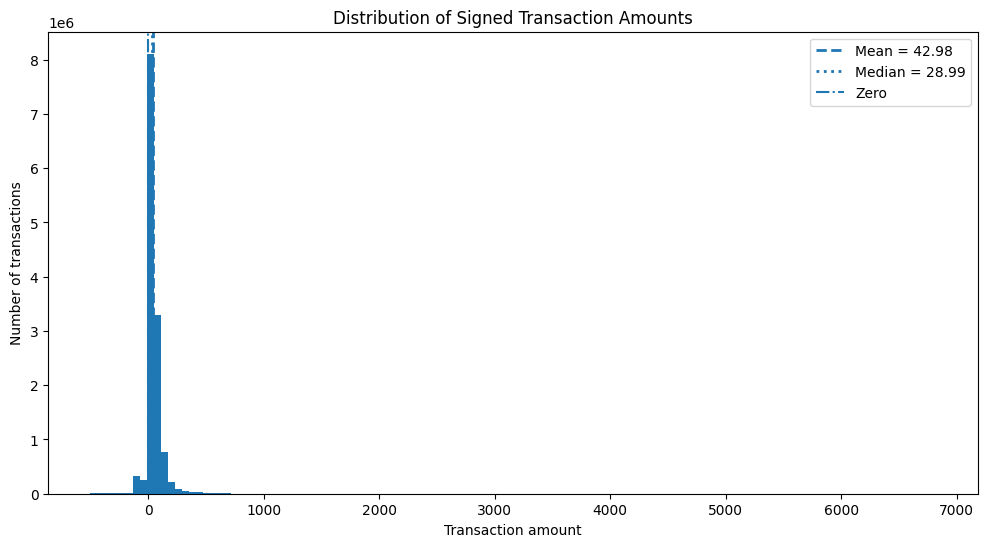

In [63]:
import matplotlib.pyplot as plt


signed_values = amounts[
    "amount"
]


signed_mean = (
    signed_values.mean()
)

signed_median = (
    signed_values.median()
)


plt.figure(
    figsize=(12, 6)
)

plt.hist(
    signed_values,
    bins=120
)

plt.axvline(
    signed_mean,
    linestyle="--",
    linewidth=2,
    label=(
        f"Mean = "
        f"{signed_mean:.2f}"
    )
)

plt.axvline(
    signed_median,
    linestyle=":",
    linewidth=2,
    label=(
        f"Median = "
        f"{signed_median:.2f}"
    )
)

plt.axvline(
    0,
    linestyle="-.",
    linewidth=1.5,
    label="Zero"
)

plt.title(
    "Distribution of Signed Transaction Amounts"
)

plt.xlabel(
    "Transaction amount"
)

plt.ylabel(
    "Number of transactions"
)

plt.legend()

plt.show()

In [64]:
lower_bound = (
    amounts[
        "amount"
    ].quantile(
        0.01
    )
)

upper_bound = (
    amounts[
        "amount"
    ].quantile(
        0.99
    )
)


print(
    "1st percentile:",
    lower_bound
)

print(
    "99th percentile:",
    upper_bound
)

1st percentile: -96.0
99th percentile: 315.95


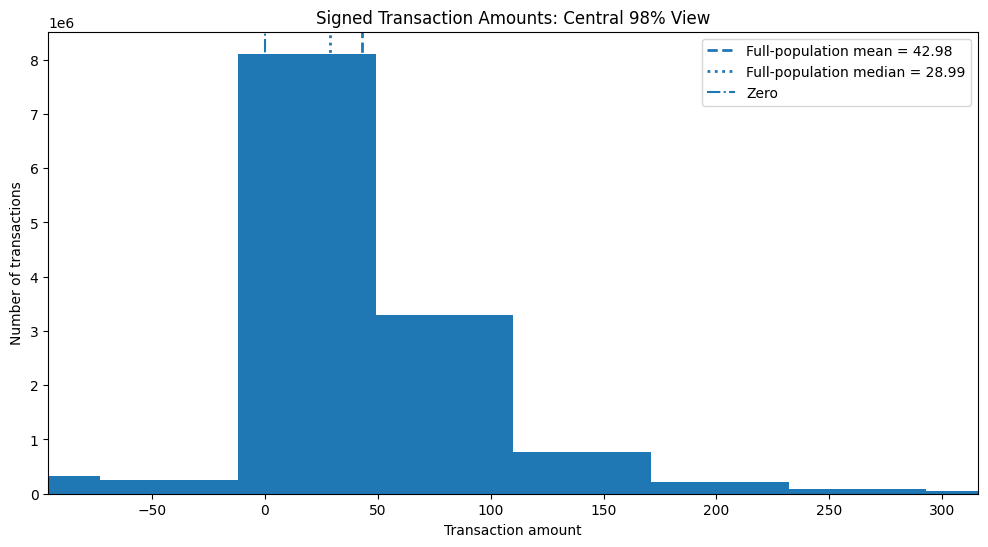

In [65]:
plt.figure(
    figsize=(12, 6)
)

plt.hist(
    signed_values,
    bins=120
)

plt.xlim(
    lower_bound,
    upper_bound
)

plt.axvline(
    signed_mean,
    linestyle="--",
    linewidth=2,
    label=(
        f"Full-population mean = "
        f"{signed_mean:.2f}"
    )
)

plt.axvline(
    signed_median,
    linestyle=":",
    linewidth=2,
    label=(
        f"Full-population median = "
        f"{signed_median:.2f}"
    )
)

plt.axvline(
    0,
    linestyle="-.",
    linewidth=1.5,
    label="Zero"
)

plt.title(
    "Signed Transaction Amounts: Central 98% View"
)

plt.xlabel(
    "Transaction amount"
)

plt.ylabel(
    "Number of transactions"
)

plt.legend()

plt.show()

In [66]:
large_amount_thresholds = {
    "absolute_amount_ge_100": (
        amounts[
            "absolute_amount"
        ]
        .ge(100)
        .sum()
    ),

    "absolute_amount_ge_250": (
        amounts[
            "absolute_amount"
        ]
        .ge(250)
        .sum()
    ),

    "absolute_amount_ge_500": (
        amounts[
            "absolute_amount"
        ]
        .ge(500)
        .sum()
    ),

    "absolute_amount_ge_1000": (
        amounts[
            "absolute_amount"
        ]
        .ge(1000)
        .sum()
    ),

    "absolute_amount_ge_2500": (
        amounts[
            "absolute_amount"
        ]
        .ge(2500)
        .sum()
    ),
}

large_amount_thresholds

{'absolute_amount_ge_100': np.int64(1651274),
 'absolute_amount_ge_250': np.int64(254668),
 'absolute_amount_ge_500': np.int64(43540),
 'absolute_amount_ge_1000': np.int64(9185),
 'absolute_amount_ge_2500': np.int64(151)}

In [67]:
large_amount_threshold_shares = {
    threshold: (
        count
        / len(amounts)
    )
    for threshold, count
    in large_amount_thresholds.items()
}

large_amount_threshold_shares

{'absolute_amount_ge_100': np.float64(0.12410074767500018),
 'absolute_amount_ge_250': np.float64(0.019139457902744756),
 'absolute_amount_ge_500': np.float64(0.0032722289297654463),
 'absolute_amount_ge_1000': np.float64(0.0006902945043614062),
 'absolute_amount_ge_2500': np.float64(1.1348336435337216e-05)}

In [68]:
central_amounts = signed_values[
    signed_values.between(
        lower_bound,
        upper_bound
    )
]

print(
    "Transactions displayed:",
    f"{len(central_amounts):,}"
)

print(
    "Share of full population:",
    len(central_amounts)
    / len(signed_values)
)

Transactions displayed: 13,047,300
Share of full population: 0.9805639071044719


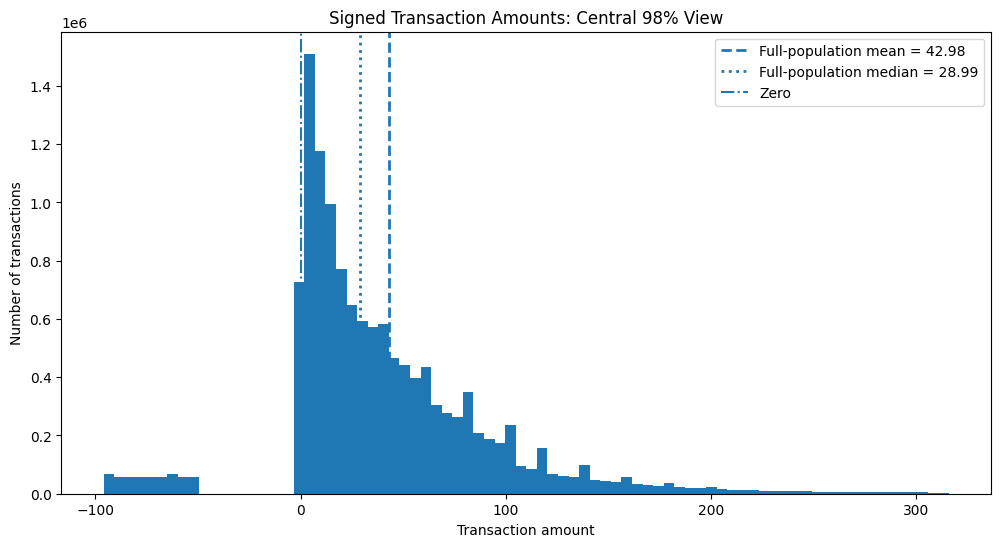

In [69]:
plt.figure(
    figsize=(12, 6)
)

plt.hist(
    central_amounts,
    bins=80
)

plt.axvline(
    signed_mean,
    linestyle="--",
    linewidth=2,
    label=f"Full-population mean = {signed_mean:.2f}"
)

plt.axvline(
    signed_median,
    linestyle=":",
    linewidth=2,
    label=f"Full-population median = {signed_median:.2f}"
)

plt.axvline(
    0,
    linestyle="-.",
    linewidth=1.5,
    label="Zero"
)

plt.title(
    "Signed Transaction Amounts: Central 98% View"
)

plt.xlabel(
    "Transaction amount"
)

plt.ylabel(
    "Number of transactions"
)

plt.legend()

plt.show()

In [70]:
channel_amounts = pd.read_csv(
    transactions_path,
    usecols=[
        "use_chip",
        "amount",
    ],
    dtype={
        "use_chip": "category",
        "amount": "float64",
    }
)

print(
    "Rows:",
    f"{len(channel_amounts):,}"
)

print(
    channel_amounts[
        "use_chip"
    ].value_counts()
)

Rows: 13,305,915
use_chip
Swipe Transaction     6967185
Chip Transaction      4780818
Online Transaction    1557912
Name: count, dtype: int64


In [71]:
assert (
    len(channel_amounts)
    == 13_305_915
)

expected_channel_counts = {
    "Swipe Transaction": 6_967_185,
    "Chip Transaction": 4_780_818,
    "Online Transaction": 1_557_912,
}

actual_channel_counts = (
    channel_amounts[
        "use_chip"
    ]
    .value_counts()
    .to_dict()
)

assert (
    actual_channel_counts
    == expected_channel_counts
)

print(
    "CHANNEL POPULATION RECONCILIATION: PASS"
)

CHANNEL POPULATION RECONCILIATION: PASS


In [72]:
channel_amounts[
    "absolute_amount"
] = (
    channel_amounts[
        "amount"
    ].abs()
)

channel_amounts[
    "amount_sign"
] = np.select(
    [
        channel_amounts["amount"] < 0,
        channel_amounts["amount"] == 0,
        channel_amounts["amount"] > 0,
    ],
    [
        "Negative",
        "Zero",
        "Positive",
    ],
    default="Unexpected"
)

In [73]:
channel_value_summary = (
    channel_amounts
    .groupby(
        "use_chip",
        observed=True
    )
    .agg(
        transaction_count=(
            "amount",
            "size"
        ),

        mean_signed_amount=(
            "amount",
            "mean"
        ),

        median_signed_amount=(
            "amount",
            "median"
        ),

        mean_absolute_amount=(
            "absolute_amount",
            "mean"
        ),

        median_absolute_amount=(
            "absolute_amount",
            "median"
        ),

        p95_absolute_amount=(
            "absolute_amount",
            lambda x:
                x.quantile(0.95)
        ),

        p99_absolute_amount=(
            "absolute_amount",
            lambda x:
                x.quantile(0.99)
        ),

        max_absolute_amount=(
            "absolute_amount",
            "max"
        ),
    )
    .reset_index()
)

channel_value_summary

,use_chip,transaction_count,mean_signed_amount,median_signed_amount,mean_absolute_amount,median_absolute_amount,p95_absolute_amount,p99_absolute_amount,max_absolute_amount
0,Online Transaction,1557912,57.256193,35.17,59.809105,35.44,190.78,409.18,6613.44
1,Swipe Transaction,6967185,41.214899,27.08,52.582604,34.65,149.76,355.00,6820.20
2,Chip Transaction,4780818,40.889150,27.04,51.736659,34.55,144.90,339.70,5591.73


In [74]:
channel_sign_summary = (
    pd.crosstab(
        channel_amounts[
            "use_chip"
        ],
        channel_amounts[
            "amount_sign"
        ]
    )
)

channel_sign_summary

amount_sign,Negative,Positive,Zero
use_chip,,,
Online Transaction,6683,1551225,4
Swipe Transaction,389176,6571735,6274
Chip Transaction,264190,4512267,4361


In [75]:
channel_sign_share = (
    pd.crosstab(
        channel_amounts[
            "use_chip"
        ],
        channel_amounts[
            "amount_sign"
        ],
        normalize="index"
    )
)

channel_sign_share

amount_sign,Negative,Positive,Zero
use_chip,,,
Online Transaction,0.004290,0.995708,0.000003
Swipe Transaction,0.055858,0.943241,0.000901
Chip Transaction,0.055260,0.943827,0.000912


In [76]:
channel_amounts[
    "large_value_500_flag"
] = (
    channel_amounts[
        "absolute_amount"
    ]
    .ge(500)
)

In [77]:
large_value_by_channel = (
    channel_amounts
    .groupby(
        "use_chip",
        observed=True
    )
    .agg(
        transaction_count=(
            "amount",
            "size"
        ),

        large_value_transactions=(
            "large_value_500_flag",
            "sum"
        ),
    )
    .reset_index()
)


large_value_by_channel[
    "large_value_transaction_rate"
] = (
    large_value_by_channel[
        "large_value_transactions"
    ]
    /
    large_value_by_channel[
        "transaction_count"
    ]
)

large_value_by_channel

,use_chip,transaction_count,large_value_transactions,large_value_transaction_rate
0,Online Transaction,1557912,8270,0.005308
1,Swipe Transaction,6967185,21449,0.003079
2,Chip Transaction,4780818,13821,0.002891


In [78]:
channel_percentiles = (
    channel_amounts
    .groupby(
        "use_chip",
        observed=True
    )[
        "absolute_amount"
    ]
    .quantile(
        [
            0.50,
            0.95,
            0.99
        ]
    )
    .unstack()
    .rename(
        columns={
            0.50: "Median",
            0.95: "P95",
            0.99: "P99"
        }
    )
)

channel_percentiles

,Median,P95,P99
use_chip,,,
Online Transaction,35.44,190.78,409.18
Swipe Transaction,34.65,149.76,355.00
Chip Transaction,34.55,144.90,339.70


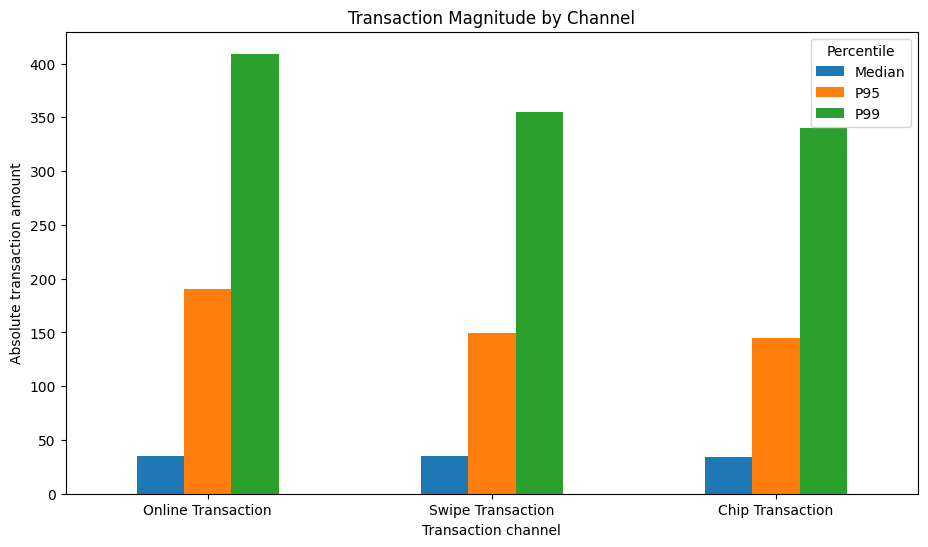

In [79]:
channel_percentiles.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Transaction Magnitude by Channel"
)

plt.xlabel(
    "Transaction channel"
)

plt.ylabel(
    "Absolute transaction amount"
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Percentile"
)

plt.show()

In [80]:
from collections import defaultdict

mcc_stats = defaultdict(
    lambda: {
        "transaction_count": 0,
        "signed_amount_sum": 0.0,
        "absolute_amount_sum": 0.0,
        "negative_count": 0,
        "zero_count": 0,
        "large_500_count": 0,
    }
)


for chunk in pd.read_csv(
    transactions_path,
    usecols=[
        "mcc",
        "amount",
    ],
    dtype={
        "mcc": "string",
        "amount": "float64",
    },
    chunksize=100_000
):

    chunk[
        "absolute_amount"
    ] = (
        chunk["amount"].abs()
    )

    chunk[
        "negative_flag"
    ] = (
        chunk["amount"] < 0
    )

    chunk[
        "zero_flag"
    ] = (
        chunk["amount"] == 0
    )

    chunk[
        "large_500_flag"
    ] = (
        chunk[
            "absolute_amount"
        ] >= 500
    )

    grouped = (
        chunk
        .groupby(
            "mcc",
            observed=True
        )
        .agg(
            transaction_count=(
                "amount",
                "size"
            ),
            signed_amount_sum=(
                "amount",
                "sum"
            ),
            absolute_amount_sum=(
                "absolute_amount",
                "sum"
            ),
            negative_count=(
                "negative_flag",
                "sum"
            ),
            zero_count=(
                "zero_flag",
                "sum"
            ),
            large_500_count=(
                "large_500_flag",
                "sum"
            ),
        )
    )

    for mcc, row in grouped.iterrows():

        record = mcc_stats[
            str(mcc).zfill(4)
        ]

        for column in record:

            record[column] += (
                row[column]
            )

In [81]:
mcc_activity = pd.DataFrame(
    [
        {
            "mcc": mcc,
            **values
        }

        for mcc, values
        in mcc_stats.items()
    ]
)

In [82]:
print(
    "MCC categories:",
    len(mcc_activity)
)

print(
    "Transactions:",
    int(
        mcc_activity[
            "transaction_count"
        ].sum()
    )
)

print(
    "Negative transactions:",
    int(
        mcc_activity[
            "negative_count"
        ].sum()
    )
)

print(
    "Large-value transactions:",
    int(
        mcc_activity[
            "large_500_count"
        ].sum()
    )
)

MCC categories: 109
Transactions: 13305915
Negative transactions: 660049
Large-value transactions: 43540


In [83]:
mcc_activity[
    "transaction_share"
] = (
    mcc_activity[
        "transaction_count"
    ]
    /
    mcc_activity[
        "transaction_count"
    ].sum()
)


mcc_activity[
    "absolute_amount_share"
] = (
    mcc_activity[
        "absolute_amount_sum"
    ]
    /
    mcc_activity[
        "absolute_amount_sum"
    ].sum()
)


mcc_activity[
    "mean_absolute_amount"
] = (
    mcc_activity[
        "absolute_amount_sum"
    ]
    /
    mcc_activity[
        "transaction_count"
    ]
)


mcc_activity[
    "negative_transaction_rate"
] = (
    mcc_activity[
        "negative_count"
    ]
    /
    mcc_activity[
        "transaction_count"
    ]
)


mcc_activity[
    "large_500_rate"
] = (
    mcc_activity[
        "large_500_count"
    ]
    /
    mcc_activity[
        "transaction_count"
    ]
)

In [84]:
mcc_reference = pd.read_csv(
    "/content/mcc_codes.csv",
    dtype={
        "mcc": "string"
    }
)

mcc_reference[
    "mcc"
] = (
    mcc_reference[
        "mcc"
    ].str.zfill(4)
)


mcc_activity = (
    mcc_activity
    .merge(
        mcc_reference,
        on="mcc",
        how="left",
        validate="one_to_one"
    )
)

In [85]:
mcc_activity.nlargest(
    10,
    "transaction_count"
)[
    [
        "mcc",
        "mcc_description",
        "transaction_count",
        "transaction_share"
    ]
]

,mcc,mcc_description,transaction_count,transaction_share
56,5411,"Grocery Stores, Supermarkets",1592584.0,0.119690
57,5499,Miscellaneous Food Stores,1460875.0,0.109791
59,5541,Service Stations,1424711.0,0.107074
69,5812,Eating Places and Restaurants,999738.0,0.075135
74,5912,Drug Stores and Pharmacies,772913.0,0.058088
41,4784,Tolls and Bridge Fees,674135.0,0.050664
53,5300,Wholesale Clubs,601942.0,0.045239
43,4829,Money Transfer,589140.0,0.044277
35,4121,Taxicabs and Limousines,500662.0,0.037627
71,5814,Fast Food Restaurants,499659.0,0.037552


In [86]:
mcc_activity.nlargest(
    10,
    "absolute_amount_sum"
)[
    [
        "mcc",
        "mcc_description",
        "absolute_amount_sum",
        "absolute_amount_share"
    ]
]

,mcc,mcc_description,absolute_amount_sum,absolute_amount_share
59,5541,Service Stations,72909084.18,0.103143
57,5499,Miscellaneous Food Stores,59142720.62,0.083668
43,4829,Money Transfer,53158515.64,0.075202
56,5411,"Grocery Stores, Supermarkets",40970779.97,0.057961
53,5300,Wholesale Clubs,37697590.68,0.053330
74,5912,Drug Stores and Pharmacies,35113606.05,0.049675
45,4900,"Utilities - Electric, Gas, Water, Sanitary",27650068.18,0.039116
55,5311,Department Stores,27032012.62,0.038242
69,5812,Eating Places and Restaurants,26348265.73,0.037274
90,7538,Automotive Service Shops,24955669.85,0.035304


In [87]:
mcc_activity.nlargest(
    10,
    "large_500_count"
)[
    [
        "mcc",
        "mcc_description",
        "large_500_count",
        "large_500_rate"
    ]
]

,mcc,mcc_description,large_500_count,large_500_rate
82,6300,"Insurance Sales, Underwriting",4302.0,0.083955
106,8111,Legal Services and Attorneys,3277.0,0.461875
40,4722,Travel Agencies,2531.0,0.079059
104,8062,Hospitals,2519.0,0.726355
2,3001,Steel Products Manufacturing,2349.0,0.754820
8,3058,"Tools, Parts, Supplies Manufacturing",2306.0,0.747730
1,3000,Steelworks,2293.0,0.748124
11,3132,Leather Goods,2136.0,0.756910
39,4511,Airlines,2114.0,0.738902
14,3256,"Brick, Stone, and Related Materials",2074.0,0.742305


In [88]:
mcc_activity.nlargest(
    10,
    "negative_count"
)[
    [
        "mcc",
        "mcc_description",
        "negative_count",
        "negative_transaction_rate"
    ]
]

,mcc,mcc_description,negative_count,negative_transaction_rate
57,5499,Miscellaneous Food Stores,290543.0,0.198883
59,5541,Service Stations,289072.0,0.202899
40,4722,Travel Agencies,9016.0,0.281627
83,7011,"Lodging - Hotels, Motels, Resorts",5263.0,0.314716
23,3504,Gardening Supplies,4991.0,0.314038
27,3684,Semiconductors and Related Devices,4964.0,0.314177
24,3509,Industrial Equipment and Supplies,4929.0,0.313769
28,3722,Passenger Railways,4868.0,0.313155
26,3640,"Lighting, Fixtures, Electrical Supplies",4643.0,0.314993
32,3780,Computer Network Services,4556.0,0.313386


In [89]:
large_value_mcc_detail = (
    mcc_activity
    .nlargest(
        15,
        "large_500_rate"
    )[
        [
            "mcc",
            "mcc_description",
            "transaction_count",
            "large_500_count",
            "large_500_rate",
            "absolute_amount_sum",
            "absolute_amount_share",
        ]
    ]
)

large_value_mcc_detail

,mcc,mcc_description,transaction_count,large_500_count,large_500_rate,absolute_amount_sum,absolute_amount_share
38,4411,Cruise Lines,428.0,362.0,0.845794,664009.44,0.000939
11,3132,Leather Goods,2822.0,2136.0,0.756910,2070957.57,0.002930
2,3001,Steel Products Manufacturing,3112.0,2349.0,0.754820,2279963.16,0.003225
1,3000,Steelworks,3065.0,2293.0,0.748124,2234633.14,0.003161
8,3058,"Tools, Parts, Supplies Manufacturing",3084.0,2306.0,0.747730,2264617.25,0.003204
5,3007,Coated and Laminated Products,381.0,283.0,0.742782,299116.16,0.000423
14,3256,"Brick, Stone, and Related Materials",2794.0,2074.0,0.742305,2001551.41,0.002832
3,3005,Miscellaneous Metal Fabrication,391.0,290.0,0.741688,296197.55,0.000419
39,4511,Airlines,2861.0,2114.0,0.738902,2088048.69,0.002954
6,3008,Steel Drums and Barrels,384.0,283.0,0.736979,306390.85,0.000433


In [90]:
large_value_count_detail = (
    mcc_activity
    .nlargest(
        15,
        "large_500_count"
    )[
        [
            "mcc",
            "mcc_description",
            "transaction_count",
            "large_500_count",
            "large_500_rate",
        ]
    ]
)

large_value_count_detail

,mcc,mcc_description,transaction_count,large_500_count,large_500_rate
82,6300,"Insurance Sales, Underwriting",51242.0,4302.0,0.083955
106,8111,Legal Services and Attorneys,7095.0,3277.0,0.461875
40,4722,Travel Agencies,32014.0,2531.0,0.079059
104,8062,Hospitals,3468.0,2519.0,0.726355
2,3001,Steel Products Manufacturing,3112.0,2349.0,0.754820
8,3058,"Tools, Parts, Supplies Manufacturing",3084.0,2306.0,0.747730
1,3000,Steelworks,3065.0,2293.0,0.748124
11,3132,Leather Goods,2822.0,2136.0,0.756910
39,4511,Airlines,2861.0,2114.0,0.738902
14,3256,"Brick, Stone, and Related Materials",2794.0,2074.0,0.742305


In [91]:
from collections import defaultdict

channel_mcc_stats = defaultdict(
    lambda: {
        "transaction_count": 0,
        "negative_count": 0,
    }
)


for chunk in pd.read_csv(
    transactions_path,
    usecols=[
        "mcc",
        "use_chip",
        "amount",
    ],
    dtype={
        "mcc": "string",
        "use_chip": "string",
        "amount": "float64",
    },
    chunksize=100_000
):

    chunk["mcc"] = (
        chunk["mcc"]
        .str.zfill(4)
    )

    chunk["negative_flag"] = (
        chunk["amount"] < 0
    )

    grouped = (
        chunk
        .groupby(
            [
                "mcc",
                "use_chip",
            ],
            observed=True
        )
        .agg(
            transaction_count=(
                "amount",
                "size"
            ),
            negative_count=(
                "negative_flag",
                "sum"
            ),
        )
    )

    for (
        mcc,
        channel
    ), row in grouped.iterrows():

        key = (
            mcc,
            channel
        )

        channel_mcc_stats[
            key
        ][
            "transaction_count"
        ] += int(
            row[
                "transaction_count"
            ]
        )

        channel_mcc_stats[
            key
        ][
            "negative_count"
        ] += int(
            row[
                "negative_count"
            ]
        )

In [92]:
channel_mcc = pd.DataFrame(
    [
        {
            "mcc": mcc,
            "use_chip": channel,
            **values,
        }

        for (
            mcc,
            channel
        ), values
        in channel_mcc_stats.items()
    ]
)


channel_mcc[
    "negative_rate"
] = (
    channel_mcc[
        "negative_count"
    ]
    /
    channel_mcc[
        "transaction_count"
    ]
)

In [93]:
channel_mcc = (
    channel_mcc
    .merge(
        mcc_reference,
        on="mcc",
        how="left",
        validate="many_to_one"
    )
)

In [94]:
channel_mcc[
    channel_mcc[
        "mcc"
    ].isin(
        [
            "5499",
            "5541",
        ]
    )
][
    [
        "mcc",
        "mcc_description",
        "use_chip",
        "transaction_count",
        "negative_count",
        "negative_rate",
    ]
].sort_values(
    [
        "mcc",
        "use_chip",
    ]
)

,mcc,mcc_description,use_chip,transaction_count,negative_count,negative_rate
227,5499,Miscellaneous Food Stores,Chip Transaction,600014,121014,0.201685
80,5499,Miscellaneous Food Stores,Swipe Transaction,860861,169529,0.196930
229,5541,Service Stations,Chip Transaction,574873,116016,0.201812
82,5541,Service Stations,Swipe Transaction,849838,173056,0.203634


In [95]:
channel_mcc[
    channel_mcc[
        "mcc"
    ].isin(
        [
            "5499",
            "5541",
        ]
    )
][
    [
        "mcc",
        "mcc_description",
        "use_chip",
        "transaction_count",
        "negative_count",
        "negative_rate",
    ]
].sort_values(
    [
        "mcc",
        "use_chip",
    ]
)

,mcc,mcc_description,use_chip,transaction_count,negative_count,negative_rate
227,5499,Miscellaneous Food Stores,Chip Transaction,600014,121014,0.201685
80,5499,Miscellaneous Food Stores,Swipe Transaction,860861,169529,0.196930
229,5541,Service Stations,Chip Transaction,574873,116016,0.201812
82,5541,Service Stations,Swipe Transaction,849838,173056,0.203634


In [96]:
dominant_negative_mccs = (
    channel_mcc[
        channel_mcc[
            "mcc"
        ].isin(
            [
                "5499",
                "5541",
            ]
        )
    ]
    .groupby(
        "use_chip",
        observed=True
    )
    .agg(
        transaction_count=(
            "transaction_count",
            "sum"
        ),
        negative_count=(
            "negative_count",
            "sum"
        ),
    )
    .reset_index()
)


dominant_negative_mccs[
    "negative_rate"
] = (
    dominant_negative_mccs[
        "negative_count"
    ]
    /
    dominant_negative_mccs[
        "transaction_count"
    ]
)

dominant_negative_mccs

,use_chip,transaction_count,negative_count,negative_rate
0,Chip Transaction,1174887,237030,0.201747
1,Swipe Transaction,1710699,342585,0.200260


In [97]:
# ============================================================
# NEGATIVE RATES BY CHANNEL
# EXCLUDING DOMINANT NEGATIVE MCCs
# ============================================================

dominant_negative_mcc_codes = {
    "5499",
    "5541",
}

remaining_channel_stats = {}


for chunk in pd.read_csv(
    transactions_path,
    usecols=[
        "mcc",
        "use_chip",
        "amount",
    ],
    dtype={
        "mcc": "string",
        "use_chip": "string",
        "amount": "float64",
    },
    chunksize=100_000
):

    chunk["mcc"] = (
        chunk["mcc"]
        .str.zfill(4)
    )

    # Remove only MCC 5499 and 5541
    chunk = chunk[
        ~chunk["mcc"].isin(
            dominant_negative_mcc_codes
        )
    ].copy()

    chunk["negative_flag"] = (
        chunk["amount"] < 0
    )

    grouped = (
        chunk
        .groupby(
            "use_chip",
            observed=True
        )
        .agg(
            transaction_count=(
                "amount",
                "size"
            ),
            negative_count=(
                "negative_flag",
                "sum"
            ),
        )
    )

    for channel, row in grouped.iterrows():

        if channel not in remaining_channel_stats:

            remaining_channel_stats[channel] = {
                "transaction_count": 0,
                "negative_count": 0,
            }

        remaining_channel_stats[
            channel
        ][
            "transaction_count"
        ] += int(
            row[
                "transaction_count"
            ]
        )

        remaining_channel_stats[
            channel
        ][
            "negative_count"
        ] += int(
            row[
                "negative_count"
            ]
        )

In [98]:
channel_negative_excluding_dominant_mccs = (
    pd.DataFrame(
        [
            {
                "use_chip": channel,
                **values,
            }

            for channel, values
            in remaining_channel_stats.items()
        ]
    )
)


channel_negative_excluding_dominant_mccs[
    "negative_rate"
] = (
    channel_negative_excluding_dominant_mccs[
        "negative_count"
    ]
    /
    channel_negative_excluding_dominant_mccs[
        "transaction_count"
    ]
)


channel_negative_excluding_dominant_mccs

,use_chip,transaction_count,negative_count,negative_rate
0,Online Transaction,1557912,6683,0.004290
1,Swipe Transaction,5256486,46591,0.008864
2,Chip Transaction,3605931,27160,0.007532


In [99]:
original_channel_negative = (
    channel_amounts
    .groupby(
        "use_chip",
        observed=True
    )
    .agg(
        transaction_count=(
            "amount",
            "size"
        ),
        negative_count=(
            "amount",
            lambda x: (x < 0).sum()
        ),
    )
    .reset_index()
)


original_channel_negative[
    "negative_rate"
] = (
    original_channel_negative[
        "negative_count"
    ]
    /
    original_channel_negative[
        "transaction_count"
    ]
)

In [100]:
negative_rate_comparison = (
    original_channel_negative[
        [
            "use_chip",
            "negative_rate",
        ]
    ]
    .rename(
        columns={
            "negative_rate":
                "original_negative_rate"
        }
    )
    .merge(
        channel_negative_excluding_dominant_mccs[
            [
                "use_chip",
                "negative_rate",
            ]
        ]
        .rename(
            columns={
                "negative_rate":
                    "negative_rate_excluding_5499_5541"
            }
        ),
        on="use_chip",
        how="left",
        validate="one_to_one"
    )
)


negative_rate_comparison[
    "rate_reduction"
] = (
    negative_rate_comparison[
        "original_negative_rate"
    ]
    -
    negative_rate_comparison[
        "negative_rate_excluding_5499_5541"
    ]
)


negative_rate_comparison[
    "relative_rate_reduction"
] = (
    negative_rate_comparison[
        "rate_reduction"
    ]
    /
    negative_rate_comparison[
        "original_negative_rate"
    ]
)


negative_rate_comparison

,use_chip,original_negative_rate,negative_rate_excluding_5499_5541,rate_reduction,relative_rate_reduction
0,Online Transaction,0.004290,0.004290,0.000000,0.000000
1,Swipe Transaction,0.055858,0.008864,0.046995,0.841322
2,Chip Transaction,0.055260,0.007532,0.047728,0.863699


In [101]:
from collections import defaultdict

merchant_stats = defaultdict(
    lambda: {
        "transaction_count": 0,
        "signed_amount_sum": 0.0,
        "absolute_amount_sum": 0.0,
        "negative_count": 0,
        "large_500_count": 0,
    }
)


for chunk in pd.read_csv(
    transactions_path,
    usecols=[
        "merchant_id",
        "amount",
    ],
    dtype={
        "merchant_id": "string",
        "amount": "float64",
    },
    chunksize=100_000
):

    chunk["absolute_amount"] = (
        chunk["amount"].abs()
    )

    chunk["negative_flag"] = (
        chunk["amount"] < 0
    )

    chunk["large_500_flag"] = (
        chunk["absolute_amount"] >= 500
    )

    grouped = (
        chunk
        .groupby(
            "merchant_id",
            observed=True
        )
        .agg(
            transaction_count=(
                "amount",
                "size"
            ),

            signed_amount_sum=(
                "amount",
                "sum"
            ),

            absolute_amount_sum=(
                "absolute_amount",
                "sum"
            ),

            negative_count=(
                "negative_flag",
                "sum"
            ),

            large_500_count=(
                "large_500_flag",
                "sum"
            ),
        )
    )

    for merchant_id, row in grouped.iterrows():

        record = merchant_stats[
            merchant_id
        ]

        record[
            "transaction_count"
        ] += int(
            row["transaction_count"]
        )

        record[
            "signed_amount_sum"
        ] += float(
            row["signed_amount_sum"]
        )

        record[
            "absolute_amount_sum"
        ] += float(
            row["absolute_amount_sum"]
        )

        record[
            "negative_count"
        ] += int(
            row["negative_count"]
        )

        record[
            "large_500_count"
        ] += int(
            row["large_500_count"]
        )

In [102]:
merchant_activity = pd.DataFrame(
    [
        {
            "merchant_id": merchant_id,
            **values
        }

        for merchant_id, values
        in merchant_stats.items()
    ]
)

In [103]:
merchant_reconciliation = {
    "distinct_merchants": (
        len(
            merchant_activity
        )
    ),

    "transactions": (
        merchant_activity[
            "transaction_count"
        ].sum()
    ),

    "negative_transactions": (
        merchant_activity[
            "negative_count"
        ].sum()
    ),

    "large_500_transactions": (
        merchant_activity[
            "large_500_count"
        ].sum()
    ),
}

merchant_reconciliation

{'distinct_merchants': 74831,
 'transactions': np.int64(13305915),
 'negative_transactions': np.int64(660049),
 'large_500_transactions': np.int64(43540)}

In [104]:
merchant_activity[
    [
        "transaction_count",
        "absolute_amount_sum",
    ]
].describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

,transaction_count,absolute_amount_sum
count,74831.000000,7.483100e+04
mean,177.812872,9.446267e+03
std,5486.420562,3.152715e+05
min,1.000000,6.000000e-02
50%,3.000000,1.933500e+02
75%,17.000000,1.041980e+03
90%,100.000000,5.447650e+03
95%,243.000000,1.199330e+04
99%,1168.000000,5.068703e+04
max,610053.000000,5.315852e+07


In [105]:
merchant_by_volume = (
    merchant_activity
    .sort_values(
        "transaction_count",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


total_transactions = (
    merchant_by_volume[
        "transaction_count"
    ].sum()
)

In [106]:
merchant_concentration = {}

for percentage in [
    0.01,
    0.05,
    0.10,
    0.20,
]:

    merchant_count = int(
        len(
            merchant_by_volume
        )
        * percentage
    )

    transaction_share = (
        merchant_by_volume
        .head(
            merchant_count
        )[
            "transaction_count"
        ]
        .sum()
        /
        total_transactions
    )

    merchant_concentration[
        f"top_{int(percentage * 100)}_percent_merchant_count"
    ] = merchant_count

    merchant_concentration[
        f"top_{int(percentage * 100)}_percent_transaction_share"
    ] = transaction_share


merchant_concentration

{'top_1_percent_merchant_count': 748,
 'top_1_percent_transaction_share': np.float64(0.7866975702159529),
 'top_5_percent_merchant_count': 3741,
 'top_5_percent_transaction_share': np.float64(0.9048556976352247),
 'top_10_percent_merchant_count': 7483,
 'top_10_percent_transaction_share': np.float64(0.9480428816808164),
 'top_20_percent_merchant_count': 14966,
 'top_20_percent_transaction_share': np.float64(0.9785124134642376)}

In [107]:
merchant_activity.nlargest(
    15,
    "transaction_count"
)[
    [
        "merchant_id",
        "transaction_count",
        "absolute_amount_sum",
        "negative_count",
        "large_500_count",
    ]
]

,merchant_id,transaction_count,absolute_amount_sum,negative_count,large_500_count
5175,59935,610053,35712266.95,178424,0
1837,27092,589140,53158515.64,0,1
5317,61195,562410,29152617.55,114363,0
3044,39021,440281,15725426.31,7,0
3488,43293,362842,21371156.52,105000,0
1322,22204,347511,17771512.68,69354,0
501,14528,333505,440575.09,4,0
5247,60569,301657,18900017.57,4,453
4247,50783,298231,7717218.45,4,4
6791,75781,273351,6692831.28,6,1


In [108]:
merchant_activity.nlargest(
    15,
    "absolute_amount_sum"
)[
    [
        "merchant_id",
        "transaction_count",
        "absolute_amount_sum",
        "negative_count",
        "large_500_count",
    ]
]

,merchant_id,transaction_count,absolute_amount_sum,negative_count,large_500_count
1837,27092,589140,53158515.64,0,1
5175,59935,610053,35712266.95,178424,0
5317,61195,562410,29152617.55,114363,0
3488,43293,362842,21371156.52,105000,0
5247,60569,301657,18900017.57,4,453
1322,22204,347511,17771512.68,69354,0
3044,39021,440281,15725426.31,7,0
6537,73186,105351,11664842.01,2,31
1149,20561,202639,8995673.10,4,0
1802,26810,162505,8866018.36,35702,0


In [109]:
merchant_mcc_pairs = set()

for chunk in pd.read_csv(
    transactions_path,
    usecols=[
        "merchant_id",
        "mcc",
    ],
    dtype={
        "merchant_id": "string",
        "mcc": "string",
    },
    chunksize=100_000
):

    chunk["mcc"] = (
        chunk["mcc"]
        .str.zfill(4)
    )

    merchant_mcc_pairs.update(
        zip(
            chunk["merchant_id"],
            chunk["mcc"],
        )
    )


merchant_mcc = pd.DataFrame(
    merchant_mcc_pairs,
    columns=[
        "merchant_id",
        "mcc",
    ]
)

In [110]:
merchant_mcc_counts = (
    merchant_mcc
    .groupby(
        "merchant_id"
    )[
        "mcc"
    ]
    .nunique()
)


merchant_mcc_checks = {
    "merchants_checked": (
        merchant_mcc_counts.size
    ),

    "merchants_with_one_mcc": (
        merchant_mcc_counts
        .eq(1)
        .sum()
    ),

    "merchants_with_multiple_mccs": (
        merchant_mcc_counts
        .gt(1)
        .sum()
    ),

    "maximum_mccs_per_merchant": (
        merchant_mcc_counts.max()
    ),
}

merchant_mcc_checks

{'merchants_checked': 74831,
 'merchants_with_one_mcc': np.int64(74375),
 'merchants_with_multiple_mccs': np.int64(456),
 'maximum_mccs_per_merchant': 2}

In [112]:
merchant_context = (
    merchant_activity
    .merge(
        merchant_mcc,
        on="merchant_id",
        how="left",
        validate="one_to_many"
    )
    .merge(
        mcc_reference,
        on="mcc",
        how="left",
        validate="many_to_one"
    )
)

In [113]:
merchant_context[
    "mean_absolute_amount"
] = (
    merchant_context[
        "absolute_amount_sum"
    ]
    /
    merchant_context[
        "transaction_count"
    ]
)


merchant_context[
    "negative_rate"
] = (
    merchant_context[
        "negative_count"
    ]
    /
    merchant_context[
        "transaction_count"
    ]
)


merchant_context[
    "large_500_rate"
] = (
    merchant_context[
        "large_500_count"
    ]
    /
    merchant_context[
        "transaction_count"
    ]
)

In [114]:
merchant_context.nlargest(
    15,
    "transaction_count"
)[
    [
        "merchant_id",
        "mcc",
        "mcc_description",
        "transaction_count",
        "absolute_amount_sum",
        "mean_absolute_amount",
        "negative_rate",
        "large_500_rate",
    ]
]

,merchant_id,mcc,mcc_description,transaction_count,absolute_amount_sum,mean_absolute_amount,negative_rate,large_500_rate
5265,59935,5499,Miscellaneous Food Stores,610053,35712266.95,58.539614,0.292473,0.000000
1862,27092,4829,Money Transfer,589140,53158515.64,90.230702,0.000000,0.000002
5409,61195,5541,Service Stations,562410,29152617.55,51.835169,0.203345,0.000000
3095,39021,4784,Tolls and Bridge Fees,440281,15725426.31,35.716795,0.000016,0.000000
3547,43293,5499,Miscellaneous Food Stores,362842,21371156.52,58.899346,0.289382,0.000000
1338,22204,5541,Service Stations,347511,17771512.68,51.139425,0.199574,0.000000
503,14528,5499,Miscellaneous Food Stores,333505,440575.09,1.321045,0.000012,0.000000
5338,60569,5300,Wholesale Clubs,301657,18900017.57,62.654000,0.000013,0.001502
4319,50783,5411,"Grocery Stores, Supermarkets",298231,7717218.45,25.876647,0.000013,0.000013
6905,75781,5411,"Grocery Stores, Supermarkets",273351,6692831.28,24.484386,0.000022,0.000004


In [115]:
merchant_context.nlargest(
    15,
    "absolute_amount_sum"
)[
    [
        "merchant_id",
        "mcc",
        "mcc_description",
        "transaction_count",
        "absolute_amount_sum",
        "mean_absolute_amount",
        "negative_rate",
        "large_500_rate",
    ]
]

,merchant_id,mcc,mcc_description,transaction_count,absolute_amount_sum,mean_absolute_amount,negative_rate,large_500_rate
1862,27092,4829,Money Transfer,589140,53158515.64,90.230702,0.000000,0.000002
5265,59935,5499,Miscellaneous Food Stores,610053,35712266.95,58.539614,0.292473,0.000000
5409,61195,5541,Service Stations,562410,29152617.55,51.835169,0.203345,0.000000
3547,43293,5499,Miscellaneous Food Stores,362842,21371156.52,58.899346,0.289382,0.000000
5338,60569,5300,Wholesale Clubs,301657,18900017.57,62.654000,0.000013,0.001502
1338,22204,5541,Service Stations,347511,17771512.68,51.139425,0.199574,0.000000
3095,39021,4784,Tolls and Bridge Fees,440281,15725426.31,35.716795,0.000016,0.000000
6647,73186,4814,Telecommunication Services,105351,11664842.01,110.723600,0.000019,0.000294
1159,20561,5912,Drug Stores and Pharmacies,202639,8995673.10,44.392605,0.000020,0.000000
1827,26810,5541,Service Stations,162505,8866018.36,54.558434,0.219698,0.000000


In [116]:
# ============================================================
# PHASE 10.8
# FAST GEOGRAPHIC EDA
# ============================================================

from collections import defaultdict
import pandas as pd


geo_stats = {
    "merchant_city": defaultdict(int),
    "merchant_state": defaultdict(int),
}

physical_transactions = 0
online_transactions = 0


for chunk in pd.read_csv(
    transactions_path,
    usecols=[
        "use_chip",
        "merchant_city",
        "merchant_state",
    ],
    dtype={
        "use_chip": "string",
        "merchant_city": "string",
        "merchant_state": "string",
    },
    chunksize=100_000
):

    online_mask = (
        chunk["use_chip"]
        == "Online Transaction"
    )

    online_transactions += int(
        online_mask.sum()
    )

    physical = chunk[
        ~online_mask
    ].copy()

    physical_transactions += len(
        physical
    )

    # Exclude synthetic ONLINE location marker
    physical = physical[
        physical["merchant_city"]
        != "ONLINE"
    ]

    city_counts = (
        physical[
            "merchant_city"
        ]
        .dropna()
        .value_counts()
    )

    for city, count in city_counts.items():
        geo_stats[
            "merchant_city"
        ][city] += int(count)

    state_counts = (
        physical[
            "merchant_state"
        ]
        .dropna()
        .value_counts()
    )

    for state, count in state_counts.items():
        geo_stats[
            "merchant_state"
        ][state] += int(count)


city_activity = (
    pd.Series(
        geo_stats["merchant_city"],
        name="transaction_count"
    )
    .sort_values(
        ascending=False
    )
    .rename_axis(
        "merchant_city"
    )
    .reset_index()
)


state_activity = (
    pd.Series(
        geo_stats["merchant_state"],
        name="transaction_count"
    )
    .sort_values(
        ascending=False
    )
    .rename_axis(
        "merchant_state"
    )
    .reset_index()
)


print(
    "Physical transactions:",
    f"{physical_transactions:,}"
)

print(
    "Online transactions:",
    f"{online_transactions:,}"
)

print(
    "Distinct physical merchant cities:",
    f"{len(city_activity):,}"
)

print(
    "Distinct physical merchant states/regions:",
    f"{len(state_activity):,}"
)

Physical transactions: 11,748,003
Online transactions: 1,557,912
Distinct physical merchant cities: 12,491
Distinct physical merchant states/regions: 199


In [117]:
city_activity.head(15)

,merchant_city,transaction_count
0,Houston,146917
1,Miami,87388
2,Brooklyn,84020
3,Los Angeles,82004
4,Chicago,72540
5,Dallas,71864
6,Louisville,66088
7,Philadelphia,61419
8,San Antonio,59265
9,Indianapolis,58258


In [118]:
state_activity.head(15)

,merchant_state,transaction_count
0,CA,1427087
1,TX,1010207
2,NY,857510
3,FL,701623
4,OH,484122
5,IL,467931
6,NC,429427
7,PA,417766
8,MI,397970
9,GA,368206


In [119]:
total_physical_location_transactions = (
    city_activity[
        "transaction_count"
    ].sum()
)


city_concentration = {
    "top_1_city_share": (
        city_activity
        .head(1)[
            "transaction_count"
        ].sum()
        /
        total_physical_location_transactions
    ),

    "top_5_city_share": (
        city_activity
        .head(5)[
            "transaction_count"
        ].sum()
        /
        total_physical_location_transactions
    ),

    "top_10_city_share": (
        city_activity
        .head(10)[
            "transaction_count"
        ].sum()
        /
        total_physical_location_transactions
    ),

    "top_25_city_share": (
        city_activity
        .head(25)[
            "transaction_count"
        ].sum()
        /
        total_physical_location_transactions
    ),
}

city_concentration

{'top_1_city_share': np.float64(0.012511864243671232),
 'top_5_city_share': np.float64(0.04027085179414616),
 'top_10_city_share': np.float64(0.06725843463094484),
 'top_25_city_share': np.float64(0.13167047273448834)}

In [120]:
# ============================================================
# PHASE 10.9
# TRANSACTION ERROR ANALYSIS
# ============================================================

import pandas as pd


error_data = pd.read_csv(
    transactions_path,
    usecols=[
        "use_chip",
        "amount",
        "errors",
    ],
    dtype={
        "use_chip": "string",
        "amount": "float64",
        "errors": "string",
    }
)


# ------------------------------------------------------------
# Reconcile population
# ------------------------------------------------------------

assert len(error_data) == 13_305_915


# ------------------------------------------------------------
# Error presence
# ------------------------------------------------------------

error_data[
    "error_present"
] = (
    error_data[
        "errors"
    ].notna()
)


error_data[
    "absolute_amount"
] = (
    error_data[
        "amount"
    ].abs()
)


error_presence_summary = {
    "total_transactions": (
        len(error_data)
    ),

    "transactions_with_recorded_error": (
        error_data[
            "error_present"
        ].sum()
    ),

    "transactions_without_recorded_error": (
        (
            ~error_data[
                "error_present"
            ]
        ).sum()
    ),

    "recorded_error_rate": (
        error_data[
            "error_present"
        ].mean()
    ),
}

error_presence_summary

{'total_transactions': 13305915,
 'transactions_with_recorded_error': np.int64(211393),
 'transactions_without_recorded_error': np.int64(13094522),
 'recorded_error_rate': np.float64(0.015887144927650598)}

In [121]:
error_type_summary = (
    error_data.loc[
        error_data[
            "error_present"
        ],
        "errors"
    ]
    .value_counts()
    .rename_axis(
        "error_value"
    )
    .reset_index(
        name="transaction_count"
    )
)


error_type_summary[
    "share_of_error_transactions"
] = (
    error_type_summary[
        "transaction_count"
    ]
    /
    error_type_summary[
        "transaction_count"
    ].sum()
)


error_type_summary

,error_value,transaction_count,share_of_error_transactions
0,Insufficient Balance,130902,0.619235
1,Bad PIN,32119,0.15194
2,Technical Glitch,26271,0.124276
3,Bad Card Number,7767,0.036742
4,Bad Expiration,6161,0.029145
5,Bad CVV,6106,0.028885
6,Bad Zipcode,1126,0.005327
7,"Bad PIN,Insufficient Balance",293,0.001386
8,"Insufficient Balance,Technical Glitch",243,0.00115
9,"Bad Card Number,Insufficient Balance",71,0.000336


In [122]:
error_type_summary.head(10)

,error_value,transaction_count,share_of_error_transactions
0,Insufficient Balance,130902,0.619235
1,Bad PIN,32119,0.15194
2,Technical Glitch,26271,0.124276
3,Bad Card Number,7767,0.036742
4,Bad Expiration,6161,0.029145
5,Bad CVV,6106,0.028885
6,Bad Zipcode,1126,0.005327
7,"Bad PIN,Insufficient Balance",293,0.001386
8,"Insufficient Balance,Technical Glitch",243,0.00115
9,"Bad Card Number,Insufficient Balance",71,0.000336


In [123]:
error_by_channel = (
    error_data
    .groupby(
        "use_chip",
        observed=True
    )
    .agg(
        transaction_count=(
            "amount",
            "size"
        ),

        recorded_error_count=(
            "error_present",
            "sum"
        ),
    )
    .reset_index()
)


error_by_channel[
    "recorded_error_rate"
] = (
    error_by_channel[
        "recorded_error_count"
    ]
    /
    error_by_channel[
        "transaction_count"
    ]
)


error_by_channel

,use_chip,transaction_count,recorded_error_count,recorded_error_rate
0,Chip Transaction,4780818,72294,0.015122
1,Online Transaction,1557912,35561,0.022826
2,Swipe Transaction,6967185,103538,0.014861


In [124]:
error_value_summary = (
    error_data
    .groupby(
        "error_present",
        observed=True
    )
    .agg(
        transaction_count=(
            "amount",
            "size"
        ),

        mean_signed_amount=(
            "amount",
            "mean"
        ),

        median_signed_amount=(
            "amount",
            "median"
        ),

        mean_absolute_amount=(
            "absolute_amount",
            "mean"
        ),

        median_absolute_amount=(
            "absolute_amount",
            "median"
        ),

        p95_absolute_amount=(
            "absolute_amount",
            lambda x:
                x.quantile(0.95)
        ),

        p99_absolute_amount=(
            "absolute_amount",
            lambda x:
                x.quantile(0.99)
        ),
    )
    .reset_index()
)


error_value_summary

,error_present,transaction_count,mean_signed_amount,median_signed_amount,mean_absolute_amount,median_absolute_amount,p95_absolute_amount,p99_absolute_amount
0,False,13094522,42.701461,28.60,52.903060,34.39,154.24,359.93
1,True,211393,59.984472,57.04,66.858063,60.67,149.62,240.00


In [125]:
# ============================================================
# PHASE 10.10
# FRAUD-LABELLED TRANSACTION EDA
# ============================================================

import pandas as pd


fraud_labels = pd.read_csv(
    "/content/fraud_labels.csv",
    dtype={
        "transaction_id": "int64",
        "fraud_label": "category",
    }
)


print(
    "Fraud labels:",
    f"{len(fraud_labels):,}"
)

print(
    fraud_labels[
        "fraud_label"
    ].value_counts()
)

Fraud labels: 8,914,963
fraud_label
No     8901631
Yes      13332
Name: count, dtype: int64
